# Importação das bibliotecas

In [3461]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier , ExtraTreesClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , classification_report , roc_auc_score ,roc_curve , precision_recall_curve, average_precision_score
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import statsmodels.api as sm
from patsy import dmatrices

In [3462]:
df_dados = pd.read_csv("german_credit_data.csv-2.xls")


display(df_dados.head())

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


# Analisando as informações do DataFrame

In [3463]:
df_dados = df_dados.rename({'Unnamed: 0' : 'id'},axis = 1)
df_dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 115.1 KB


Observe que há valores faltantes nas colunas de Saving accounts e Checking Accounts. Vamos plotar para entender o comportamento dessas variáveis

In [3464]:
print(df_dados['Saving accounts'].value_counts() , df_dados['Checking account'].value_counts())

Saving accounts
little        603
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64 Checking account
little      274
moderate    269
rich         63
Name: count, dtype: int64


In [3465]:
Saving_accounts = df_dados[['Saving accounts' , 'Risk' ]].groupby('Saving accounts', as_index = False).value_counts()
Saving_accounts.head()
Checking_account = df_dados[['Checking account' , 'Risk' ]].groupby('Checking account', as_index = False).value_counts()
Checking_account.head()

,Checking account,Risk,count
0,little,good,139
1,little,bad,135
2,moderate,good,164
3,moderate,bad,105
4,rich,good,49


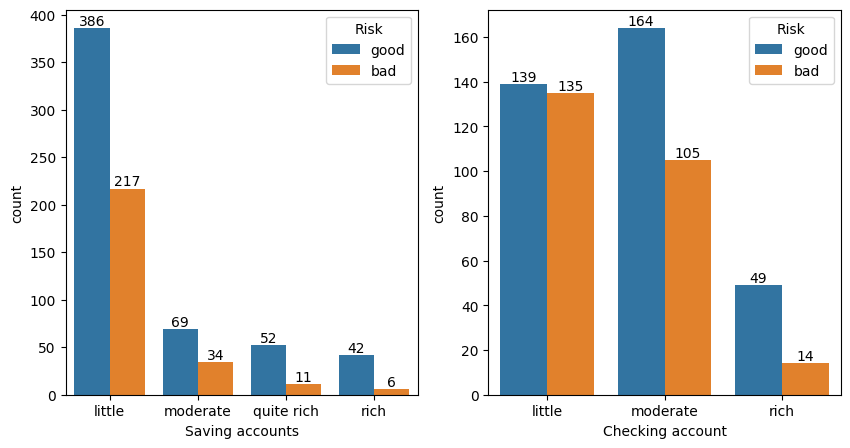

In [3466]:
fig , ax = plt.subplots(figsize = (10 , 5) , nrows = 1 , ncols = 2)
ax0 = sns.barplot(data = Saving_accounts , x = 'Saving accounts' , y = "count" , ax = ax[0] , hue = 'Risk')
ax1 = sns.barplot(data = Checking_account , x = 'Checking account' , y = 'count' , ax = ax[1] , hue = 'Risk')

ax0.bar_label(ax0.containers[0])
ax0.bar_label(ax0.containers[1])
ax1.bar_label(ax1.containers[0])
ax1.bar_label(ax1.containers[1])


plt.show()

Pelo plot acima, podemos entender que a classe de pessoas ricas tem maior percentual de bons pagadores em comparação com as demais. Para os valores faltantes de cada uma das categorias, vamos usar um modelo de Random Forest, com a variável dependente sendo a variável que queremos preencher. Nossos dados de treino são todos os dados que temos e os de teste são os dados não preenchidos.  

### Preenchendo Saving accounts

In [3467]:
faltantes = df_dados.copy()
faltantes = faltantes.dropna()
display(faltantes.shape[0])

522

In [3468]:
duas_colunas = df_dados[(df_dados['Saving accounts'].isna()) & (df_dados['Checking account'].isna())]
display(duas_colunas)

,id,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
5,5,35,male,1,free,NaN,NaN,9055,36,education,good
16,16,53,male,2,own,NaN,NaN,2424,24,radio/TV,good
24,24,26,male,2,own,NaN,NaN,2069,10,furniture/equipment,good
33,33,57,male,1,rent,NaN,NaN,1264,12,business,good
53,53,31,male,2,own,NaN,NaN,3378,18,car,good
...,...,...,...,...,...,...,...,...,...,...,...
947,947,38,male,3,own,NaN,NaN,2859,12,car,good
962,962,29,male,2,own,NaN,NaN,3556,15,car,good
968,968,29,male,2,rent,NaN,NaN,7166,42,radio/TV,good
990,990,37,male,1,own,NaN,NaN,3565,12,education,good


In [3469]:
df_Saving = df_dados[(df_dados['Saving accounts'].isna()) & (~df_dados['Checking account'].isna())]
display(df_Saving)

,id,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
17,17,25,male,2,own,NaN,little,8072,30,business,good
50,50,29,male,1,own,NaN,moderate,2333,24,furniture/equipment,good
56,56,52,male,3,own,NaN,moderate,6468,12,radio/TV,bad
61,61,50,male,2,own,NaN,moderate,1537,15,radio/TV,good
...,...,...,...,...,...,...,...,...,...,...,...
912,912,25,female,2,own,NaN,moderate,2991,30,radio/TV,good
956,956,49,male,1,own,NaN,rich,3656,30,radio/TV,good
965,965,26,female,2,own,NaN,moderate,1715,30,radio/TV,good
977,977,42,male,2,own,NaN,moderate,2427,18,business,good


In [3470]:
df_Checking = df_dados[(~df_dados['Saving accounts'].isna()) & (df_dados['Checking account'].isna())]
display(df_Checking)

,id,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
2,2,49,male,1,own,little,NaN,2096,12,education,good
6,6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
8,8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
19,19,31,male,2,own,quite rich,NaN,3430,24,radio/TV,good
20,20,48,male,2,own,little,NaN,2134,9,car,good
...,...,...,...,...,...,...,...,...,...,...,...
984,984,30,male,1,own,little,NaN,2028,24,furniture/equipment,good
987,987,64,female,2,own,moderate,NaN,1409,13,radio/TV,good
991,991,34,male,1,own,moderate,NaN,1569,15,radio/TV,good
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good


In [3471]:
X_train = df_dados.dropna()
y_train = X_train['Saving accounts']
X_train = X_train.drop(['Saving accounts' , 'Checking account'] , axis = 1)

display(X_train)

X_test_Saving = df_Saving.drop(['Checking account' , 'Saving accounts'] , axis = 1)



,id,Age,Sex,Job,Housing,Credit amount,Duration,Purpose,Risk
1,1,22,female,2,own,5951,48,radio/TV,bad
3,3,45,male,2,free,7882,42,furniture/equipment,good
4,4,53,male,2,free,4870,24,car,bad
7,7,35,male,3,rent,6948,36,car,good
9,9,28,male,3,own,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...
989,989,48,male,1,own,1743,24,radio/TV,good
993,993,30,male,3,own,3959,36,furniture/equipment,good
996,996,40,male,3,own,3857,30,car,good
998,998,23,male,2,free,1845,45,radio/TV,bad


In [3472]:
categoricas = ['Sex' , 'Job' , 'Housing' , 'Purpose' , 'Risk']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False , drop = 'if_binary')

colunas_transformadas = ohe.fit_transform(X_train[categoricas])

df_ohe = pd.DataFrame(colunas_transformadas , columns = ohe.get_feature_names_out() , index = X_train.index)

X_train = pd.concat([X_train.drop(categoricas , axis = 1) , df_ohe] , axis = 1)

display(X_train.columns)

Index(['id', 'Age', 'Credit amount', 'Duration', 'Sex_male', 'Job_0', 'Job_1',
       'Job_2', 'Job_3', 'Housing_free', 'Housing_own', 'Housing_rent',
       'Purpose_business', 'Purpose_car', 'Purpose_domestic appliances',
       'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV',
       'Purpose_repairs', 'Purpose_vacation/others', 'Risk_good'],
      dtype='str')

In [3473]:
y_train = y_train.replace({'little' : 0 , 'moderate' : 1 , 'quite rich' : 2 , 'rich' : 3}).astype(int)
display(y_train)

1      0
3      0
4      0
7      0
9      0
      ..
989    0
993    0
996    0
998    0
999    1
Name: Saving accounts, Length: 522, dtype: int64

In [3474]:
display(y_train.value_counts())

Saving accounts
0    412
1     64
2     23
3     23
Name: count, dtype: int64

In [3475]:
modelo = RandomForestClassifier()
modelo.fit(X_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [3476]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False , drop = 'if_binary')

colunas_transformadas = ohe.fit_transform(X_test_Saving[categoricas])

df_ohe = pd.DataFrame(colunas_transformadas , columns = ohe.get_feature_names_out() , index = X_test_Saving.index)

X_test_Saving = pd.concat([X_test_Saving.drop(categoricas , axis = 1) , df_ohe] , axis = 1)

X_test_Saving['Purpose_repairs'] = 0

display(X_test_Saving.columns)

Index(['id', 'Age', 'Credit amount', 'Duration', 'Sex_male', 'Job_0', 'Job_1',
       'Job_2', 'Job_3', 'Housing_free', 'Housing_own', 'Housing_rent',
       'Purpose_business', 'Purpose_car', 'Purpose_domestic appliances',
       'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV',
       'Purpose_vacation/others', 'Risk_good', 'Purpose_repairs'],
      dtype='str')

In [3477]:
print(X_train.columns)

Index(['id', 'Age', 'Credit amount', 'Duration', 'Sex_male', 'Job_0', 'Job_1',
       'Job_2', 'Job_3', 'Housing_free', 'Housing_own', 'Housing_rent',
       'Purpose_business', 'Purpose_car', 'Purpose_domestic appliances',
       'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV',
       'Purpose_repairs', 'Purpose_vacation/others', 'Risk_good'],
      dtype='str')


In [3478]:
X_test_Saving = X_test_Saving[['id', 'Age', 'Credit amount', 'Duration', 'Sex_male', 'Job_0', 'Job_1',
       'Job_2', 'Job_3', 'Housing_free', 'Housing_own', 'Housing_rent',
       'Purpose_business', 'Purpose_car', 'Purpose_domestic appliances',
       'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV',
       'Purpose_repairs', 'Purpose_vacation/others', 'Risk_good']]

In [3479]:
y_pred_Saving = modelo.predict(X_test_Saving)
y_pred_Saving = pd.DataFrame(y_pred_Saving , index = X_test_Saving.index , columns = ['Saving Accounts'])
y_pred_Saving.index.name = 'id'
y_pred_Saving = (y_pred_Saving).replace({0 : 'little' , 1 : 'moderate',  2 :'quite rich' , 3 : 'rich'})
display(y_pred_Saving)

,Saving Accounts
id,
0,little
17,little
50,little
56,little
61,little
...,...
912,little
956,little
965,little


In [3480]:
concat_Saving = X_test_Saving.reset_index(drop = True)
concat_Saving = concat_Saving.set_index('id')
concat_Saving['Saving accounts'] = y_pred_Saving

concat_Saving = concat_Saving.merge(df_Saving[['id' , 'Checking account']] , on = 'id' , how = 'left')

display(concat_Saving)

,id,Age,Credit amount,Duration,Sex_male,Job_0,Job_1,Job_2,Job_3,Housing_free,...,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Risk_good,Saving accounts,Checking account
0,0,67,1169,6,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0,0.0,1.0,little,little
1,17,25,8072,30,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,1.0,little,little
2,50,29,2333,24,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0,0.0,1.0,little,moderate
3,56,52,6468,12,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0,0.0,0.0,little,moderate
4,61,50,1537,15,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0,0.0,1.0,little,moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,912,25,2991,30,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0,0.0,1.0,little,moderate
80,956,49,3656,30,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0,0.0,1.0,little,rich
81,965,26,1715,30,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0,0.0,1.0,little,moderate
82,977,42,2427,18,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,1.0,little,moderate


In [3481]:
concat_Saving_categoricas = ohe.inverse_transform(concat_Saving[list(ohe.get_feature_names_out())])
concat_Saving_categoricas = pd.DataFrame(concat_Saving_categoricas , columns = categoricas , index = X_test_Saving.index)
concat_Saving = concat_Saving_categoricas.merge(df_Saving[['id' , 'Checking account']] , on = 'id' , how = 'left')
concat_Saving = concat_Saving.set_index('id')
concat_Saving['Saving accounts'] = y_pred_Saving
concat_Saving = concat_Saving.merge(df_Saving[['id' , 'Credit amount' , 'Age' , 'Duration']] , on = 'id' , how = 'left')
concat_Saving = concat_Saving.reset_index(drop = True)
concat_Saving = concat_Saving[df_Saving.columns]
display(concat_Saving)

,id,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,little,little,1169,6,radio/TV,good
1,17,25,male,2,own,little,little,8072,30,business,good
2,50,29,male,1,own,little,moderate,2333,24,furniture/equipment,good
3,56,52,male,3,own,little,moderate,6468,12,radio/TV,bad
4,61,50,male,2,own,little,moderate,1537,15,radio/TV,good
...,...,...,...,...,...,...,...,...,...,...,...
79,912,25,female,2,own,little,moderate,2991,30,radio/TV,good
80,956,49,male,1,own,little,rich,3656,30,radio/TV,good
81,965,26,female,2,own,little,moderate,1715,30,radio/TV,good
82,977,42,male,2,own,little,moderate,2427,18,business,good


In [3482]:
X_train = df_dados.dropna()
y_train = X_train['Checking account']
X_train = X_train.drop(['Saving accounts' , 'Checking account'] , axis = 1)

display(X_train)

X_test_Checking = df_Checking.drop(['Checking account' , 'Saving accounts'] , axis = 1)


,id,Age,Sex,Job,Housing,Credit amount,Duration,Purpose,Risk
1,1,22,female,2,own,5951,48,radio/TV,bad
3,3,45,male,2,free,7882,42,furniture/equipment,good
4,4,53,male,2,free,4870,24,car,bad
7,7,35,male,3,rent,6948,36,car,good
9,9,28,male,3,own,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...
989,989,48,male,1,own,1743,24,radio/TV,good
993,993,30,male,3,own,3959,36,furniture/equipment,good
996,996,40,male,3,own,3857,30,car,good
998,998,23,male,2,free,1845,45,radio/TV,bad


In [3483]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False , drop = 'if_binary')

colunas_transformadas = ohe.fit_transform(X_train[categoricas])

df_ohe = pd.DataFrame(colunas_transformadas , columns = ohe.get_feature_names_out() , index = X_train.index)

X_train = pd.concat([X_train.drop(categoricas , axis = 1) , df_ohe] , axis = 1)

display(X_train.shape)

(522, 21)

In [3484]:
y_train = y_train.replace({'little' : 0 , 'moderate' : 1  , 'rich' : 2}).astype(int)
display(y_train)

1      1
3      0
4      0
7      1
9      1
      ..
989    1
993    0
996    0
998    0
999    1
Name: Checking account, Length: 522, dtype: int64

In [3485]:
display(y_train.value_counts())
modelo.fit(X_train , y_train)


Checking account
0    245
1    224
2     53
Name: count, dtype: int64

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [3486]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False , drop = 'if_binary')

colunas_transformadas = ohe.fit_transform(X_test_Checking[categoricas])

df_ohe = pd.DataFrame(colunas_transformadas , columns = ohe.get_feature_names_out() , index = X_test_Checking.index)

X_test_Checking = pd.concat([X_test_Checking.drop(categoricas , axis = 1) , df_ohe] , axis = 1)


display(X_test_Checking.columns)

Index(['id', 'Age', 'Credit amount', 'Duration', 'Sex_male', 'Job_0', 'Job_1',
       'Job_2', 'Job_3', 'Housing_free', 'Housing_own', 'Housing_rent',
       'Purpose_business', 'Purpose_car', 'Purpose_domestic appliances',
       'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV',
       'Purpose_repairs', 'Purpose_vacation/others', 'Risk_good'],
      dtype='str')

In [3487]:
y_pred_Checking = modelo.predict(X_test_Checking)
y_pred_Checking = pd.DataFrame(y_pred_Checking , index = X_test_Checking.index , columns = ['Checking account'])
y_pred_Checking.index.name = 'id'
y_pred_Checking = (y_pred_Checking).replace({0 : 'little' , 1 : 'moderate',  2 :'rich'})
display(y_pred_Checking)

,Checking account
id,
2,little
6,little
8,little
19,moderate
20,little
...,...
984,little
987,moderate
991,moderate


In [3488]:
concat_Checking = X_test_Checking.reset_index(drop = True)
concat_Checking = concat_Checking.set_index('id')

concat_Checking_categoricas = ohe.inverse_transform(concat_Checking[list(ohe.get_feature_names_out())])
concat_Checking_categoricas = pd.DataFrame(concat_Checking_categoricas , columns = categoricas , index = X_test_Checking.index)
concat_Checking = concat_Checking_categoricas.merge(df_Checking[['id' , 'Saving accounts']] , on = 'id' , how = 'left')
concat_Checking = concat_Checking.set_index('id')
concat_Checking['Checking account'] = y_pred_Checking
concat_Checking = concat_Checking.merge(df_Checking[['id' , 'Credit amount' , 'Age' , 'Duration']] , on = 'id' , how = 'left')
concat_Checking = concat_Checking.reset_index(drop = True)
concat_Checking = concat_Checking[df_Checking.columns]
display(concat_Checking)

,id,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,2,49,male,1,own,little,little,2096,12,education,good
1,6,53,male,2,own,quite rich,little,2835,24,furniture/equipment,good
2,8,61,male,1,own,rich,little,3059,12,radio/TV,good
3,19,31,male,2,own,quite rich,moderate,3430,24,radio/TV,good
4,20,48,male,2,own,little,little,2134,9,car,good
...,...,...,...,...,...,...,...,...,...,...,...
290,984,30,male,1,own,little,little,2028,24,furniture/equipment,good
291,987,64,female,2,own,moderate,moderate,1409,13,radio/TV,good
292,991,34,male,1,own,moderate,moderate,1569,15,radio/TV,good
293,995,31,female,1,own,little,little,1736,12,furniture/equipment,good


In [3489]:
X_train = df_dados.dropna()
y_train = X_train['Saving accounts']
X_train = X_train.drop(['Saving accounts' , 'Checking account'] , axis = 1)

display(X_train)

X_test = duas_colunas.drop(['Checking account' , 'Saving accounts'] , axis = 1)

,id,Age,Sex,Job,Housing,Credit amount,Duration,Purpose,Risk
1,1,22,female,2,own,5951,48,radio/TV,bad
3,3,45,male,2,free,7882,42,furniture/equipment,good
4,4,53,male,2,free,4870,24,car,bad
7,7,35,male,3,rent,6948,36,car,good
9,9,28,male,3,own,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...
989,989,48,male,1,own,1743,24,radio/TV,good
993,993,30,male,3,own,3959,36,furniture/equipment,good
996,996,40,male,3,own,3857,30,car,good
998,998,23,male,2,free,1845,45,radio/TV,bad


In [3490]:
colunas_transformadas = ohe.fit_transform(X_train[categoricas])

df_ohe = pd.DataFrame(colunas_transformadas , columns = ohe.get_feature_names_out() , index = X_train.index)

X_train = pd.concat([X_train.drop(categoricas , axis = 1) , df_ohe] , axis = 1)

display(X_train.columns)

Index(['id', 'Age', 'Credit amount', 'Duration', 'Sex_male', 'Job_0', 'Job_1',
       'Job_2', 'Job_3', 'Housing_free', 'Housing_own', 'Housing_rent',
       'Purpose_business', 'Purpose_car', 'Purpose_domestic appliances',
       'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV',
       'Purpose_repairs', 'Purpose_vacation/others', 'Risk_good'],
      dtype='str')

In [3491]:
modelo.fit(X_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [3492]:
colunas_transformadas = ohe.fit_transform(X_test[categoricas])

df_ohe = pd.DataFrame(colunas_transformadas , columns = ohe.get_feature_names_out() , index = X_test.index)

X_test = pd.concat([X_test.drop(categoricas , axis = 1) , df_ohe] , axis = 1)

X_test['Job_0'] = 0

X_test['Purpose_vacation/others'] = 0

X_test = X_test[X_train.columns]

display(X_test.columns)

Index(['id', 'Age', 'Credit amount', 'Duration', 'Sex_male', 'Job_0', 'Job_1',
       'Job_2', 'Job_3', 'Housing_free', 'Housing_own', 'Housing_rent',
       'Purpose_business', 'Purpose_car', 'Purpose_domestic appliances',
       'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV',
       'Purpose_repairs', 'Purpose_vacation/others', 'Risk_good'],
      dtype='str')

In [3493]:
y_pred = modelo.predict(X_test)
y_pred = pd.DataFrame(y_pred , index = X_test.index , columns = ['Saving accounts'])
y_pred.index.name = 'id'
y_pred = (y_pred).replace({0 : 'little' , 1 : 'moderate',  2 :'quite rich' , 3 : 'rich'})
display(y_pred)


,Saving accounts
id,
5,little
16,little
24,little
33,moderate
53,moderate
...,...
947,little
962,little
968,little


In [3494]:
concat_intersec = X_test.reset_index(drop = True)
concat_intersec = concat_intersec.set_index('id')

concat_intersec_categoricas = ohe.inverse_transform(concat_intersec[list(ohe.get_feature_names_out())])
concat_intersec_categoricas = pd.DataFrame(concat_intersec_categoricas , columns = categoricas , index = X_test.index)
concat_intersec = concat_intersec_categoricas.merge(duas_colunas[['id' , 'Credit amount' , 'Age' , 'Duration']] , on = 'id' , how = 'left')
concat_intersec = concat_intersec.set_index('id')
concat_intersec['Saving accounts'] = y_pred

display(concat_intersec)

,Sex,Job,Housing,Purpose,Risk,Credit amount,Age,Duration,Saving accounts
id,,,,,,,,,
5,male,1,free,education,good,9055,35,36,little
16,male,2,own,radio/TV,good,2424,53,24,little
24,male,2,own,furniture/equipment,good,2069,26,10,little
33,male,1,rent,business,good,1264,57,12,moderate
53,male,2,own,car,good,3378,31,18,moderate
...,...,...,...,...,...,...,...,...,...
947,male,3,own,car,good,2859,38,12,little
962,male,2,own,car,good,3556,29,15,little
968,male,2,rent,radio/TV,good,7166,29,42,little


In [3495]:
X_train = df_dados.dropna()
y_train = X_train['Checking account']
X_train = X_train.drop(['Saving accounts' , 'Checking account'] , axis = 1)

display(X_train)

X_test = duas_colunas.drop(['Checking account' , 'Saving accounts'] , axis = 1)

,id,Age,Sex,Job,Housing,Credit amount,Duration,Purpose,Risk
1,1,22,female,2,own,5951,48,radio/TV,bad
3,3,45,male,2,free,7882,42,furniture/equipment,good
4,4,53,male,2,free,4870,24,car,bad
7,7,35,male,3,rent,6948,36,car,good
9,9,28,male,3,own,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...
989,989,48,male,1,own,1743,24,radio/TV,good
993,993,30,male,3,own,3959,36,furniture/equipment,good
996,996,40,male,3,own,3857,30,car,good
998,998,23,male,2,free,1845,45,radio/TV,bad


In [3496]:
colunas_transformadas = ohe.fit_transform(X_train[categoricas])

df_ohe = pd.DataFrame(colunas_transformadas , columns = ohe.get_feature_names_out() , index = X_train.index)

X_train = pd.concat([X_train.drop(categoricas , axis = 1) , df_ohe] , axis = 1)

display(X_train.columns)

Index(['id', 'Age', 'Credit amount', 'Duration', 'Sex_male', 'Job_0', 'Job_1',
       'Job_2', 'Job_3', 'Housing_free', 'Housing_own', 'Housing_rent',
       'Purpose_business', 'Purpose_car', 'Purpose_domestic appliances',
       'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV',
       'Purpose_repairs', 'Purpose_vacation/others', 'Risk_good'],
      dtype='str')

In [3497]:
modelo.fit(X_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [3498]:
colunas_transformadas = ohe.fit_transform(X_test[categoricas])

df_ohe = pd.DataFrame(colunas_transformadas , columns = ohe.get_feature_names_out() , index = X_test.index)

X_test = pd.concat([X_test.drop(categoricas , axis = 1) , df_ohe] , axis = 1)

X_test['Job_0'] = 0

X_test['Purpose_vacation/others'] = 0

X_test = X_test[X_train.columns]

display(X_test.columns)

Index(['id', 'Age', 'Credit amount', 'Duration', 'Sex_male', 'Job_0', 'Job_1',
       'Job_2', 'Job_3', 'Housing_free', 'Housing_own', 'Housing_rent',
       'Purpose_business', 'Purpose_car', 'Purpose_domestic appliances',
       'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV',
       'Purpose_repairs', 'Purpose_vacation/others', 'Risk_good'],
      dtype='str')

In [3499]:
y_pred = modelo.predict(X_test)
y_pred = pd.DataFrame(y_pred , index = X_test.index , columns = ['Checking account'])
y_pred.index.name = 'id'
display(y_pred)

,Checking account
id,
5,moderate
16,little
24,moderate
33,moderate
53,moderate
...,...
947,little
962,little
968,moderate


In [3500]:
concat_intersec['Checking account'] = y_pred
concat_intersec = concat_intersec[df_dados.set_index('id').columns] 
concat_intersec = concat_intersec.reset_index()
display(concat_intersec)

,id,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,5,35,male,1,free,little,moderate,9055,36,education,good
1,16,53,male,2,own,little,little,2424,24,radio/TV,good
2,24,26,male,2,own,little,moderate,2069,10,furniture/equipment,good
3,33,57,male,1,rent,moderate,moderate,1264,12,business,good
4,53,31,male,2,own,moderate,moderate,3378,18,car,good
...,...,...,...,...,...,...,...,...,...,...,...
94,947,38,male,3,own,little,little,2859,12,car,good
95,962,29,male,2,own,little,little,3556,15,car,good
96,968,29,male,2,rent,little,moderate,7166,42,radio/TV,good
97,990,37,male,1,own,little,little,3565,12,education,good


In [3501]:
dados_tratados = df_dados.dropna().reset_index(drop = True)
dados_tratados = pd.concat([dados_tratados, concat_Saving] , axis = 0 , ignore_index = True)
dados_tratados = pd.concat([dados_tratados, concat_Checking] , axis = 0 , ignore_index = True)
dados_tratados = pd.concat([dados_tratados, concat_intersec] , axis = 0 , ignore_index = True)
dados_tratados = dados_tratados.set_index('id')
dados_tratados = dados_tratados.sort_index().reset_index()

display(dados_tratados)
display(df_dados)

,id,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,little,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,little,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,little,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,moderate,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


,id,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


Como podemos ver, temos nosso dataset atualizado com os valores faltantes preenchidos com as estimativas. Agora podemos partir para a análise exploratória de dados. Vamos analisar primeiro as variáveis numéricas. Vamos excluir a coluna de id.

In [3502]:
df_analise = dados_tratados.drop(['id'] , axis = 1)

# Estatísticas descritivas das features

In [3503]:
numericas = ['Age' , 'Credit amount' , 'Duration']
categoricas = ['Sex' , 'Job' , 'Housing' , 'Saving accounts' , 'Checking account' , 'Purpose']
alvo = ['Risk']

display(df_analise.info())
display(df_analise[numericas].describe())
display(df_analise.drop(numericas , axis = 1).describe())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   str   
 2   Job               1000 non-null   object
 3   Housing           1000 non-null   str   
 4   Saving accounts   1000 non-null   object
 5   Checking account  1000 non-null   object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   str   
 9   Risk              1000 non-null   str   
dtypes: int64(3), object(3), str(4)
memory usage: 98.4+ KB


None

,Age,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000
mean,35.546000,3271.258000,20.903000
std,11.375469,2822.736876,12.058814
min,19.000000,250.000000,4.000000
25%,27.000000,1365.500000,12.000000
50%,33.000000,2319.500000,18.000000
75%,42.000000,3972.250000,24.000000
max,75.000000,18424.000000,72.000000


,Sex,Job,Housing,Saving accounts,Checking account,Purpose,Risk
count,1000,1000,1000,1000,1000,1000,1000
unique,2,4,3,4,3,8,2
top,male,2,own,little,little,car,good
freq,690,630,713,784,484,337,700


Analisando as estatísticas descritivas dos nossos dados, podemos observar que todas as variáveis numéricas apresentam comportamento que indica um leve desvio à direita, a média é maior que a mediana em todas elas (vamos verificar a seguir no plot). Sobre as variáveis categóricas, podemos observar que a nossa há mais pessoas com boa avaliação de crédito do que o contrário, o que indica que nossos dados estão levemente desbalanceados. As variáveis dependentes também possuem comportamento desbalanceado. A maioria das pessoas possue avaliação do montante em conta corrente e em poupança baixo, principalmente em poupança.

# Plot das variáveis numéricas

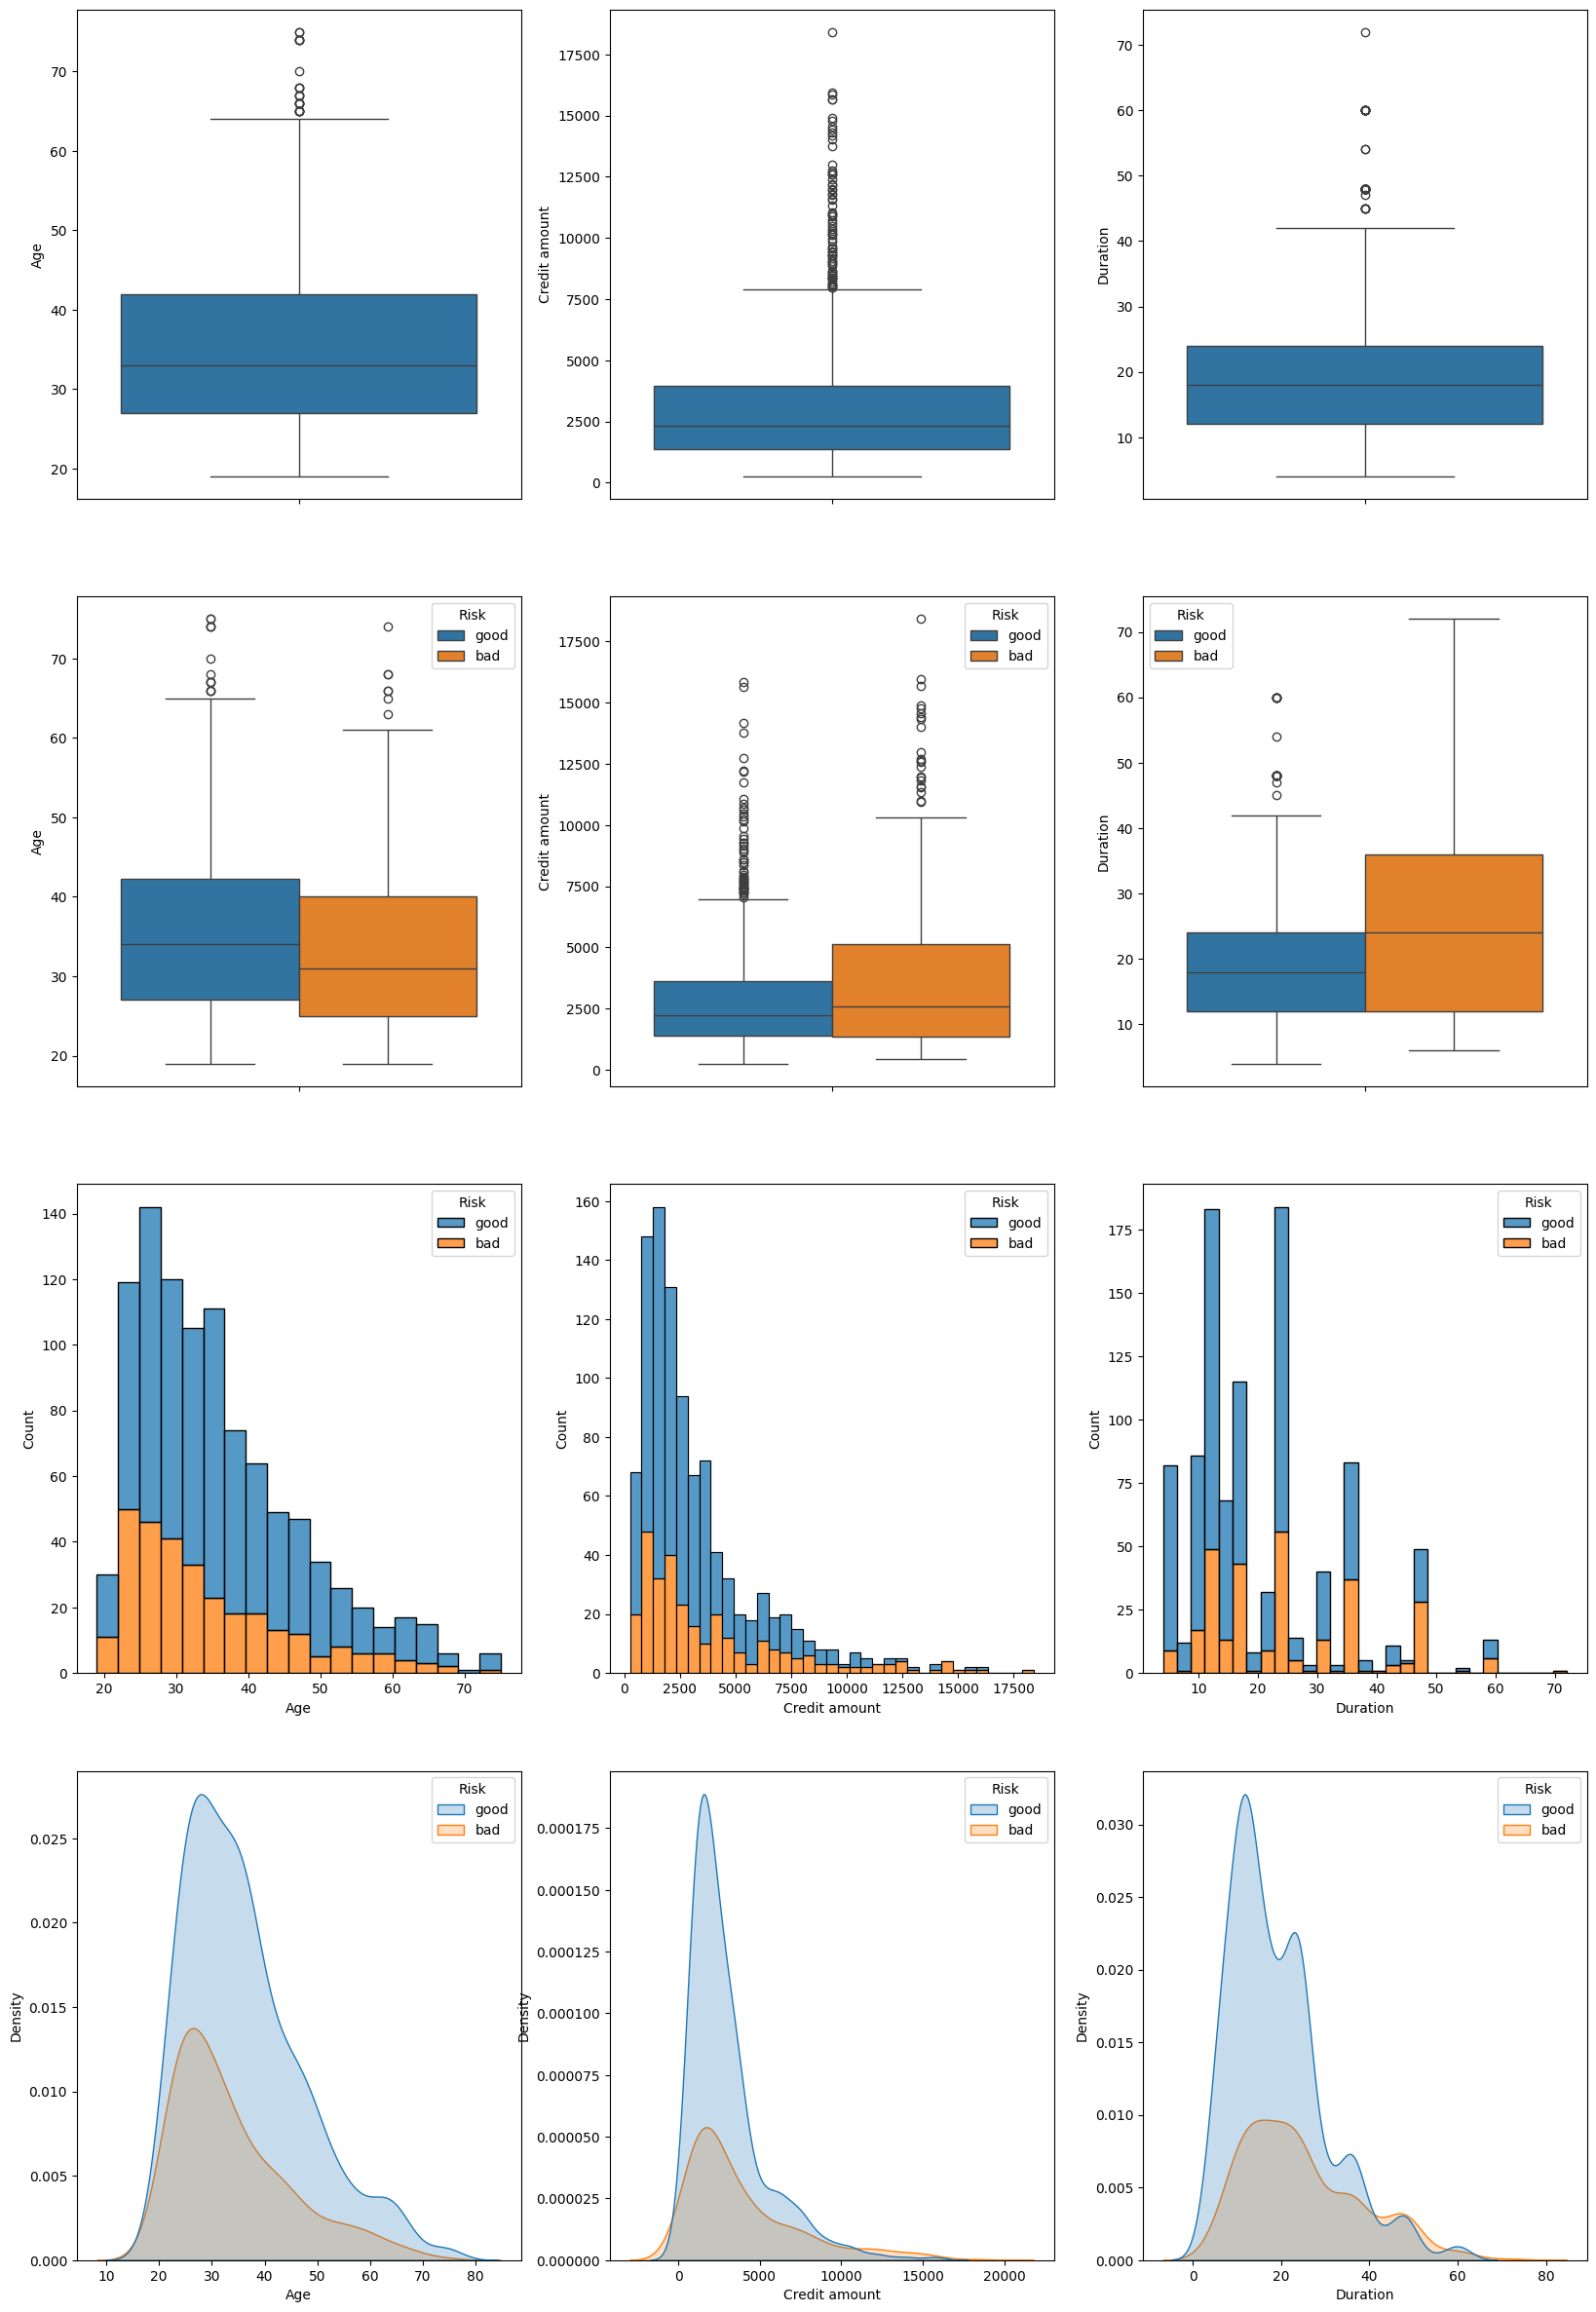

In [3504]:
fig , ax = plt.subplots(figsize = (20 , 30) , nrows = 4, ncols = 3)

for i , coluna in enumerate(numericas):
    sns.boxplot(data = df_analise , y = coluna , ax = ax[0][i])

for i , coluna in enumerate(numericas):
    sns.boxplot(data = df_analise , y = coluna , ax = ax[1][i] , hue = 'Risk')

for i , coluna in enumerate(numericas):
    sns.histplot(data = df_analise , x = coluna , ax = ax[2][i] , hue = 'Risk' , multiple = 'stack')

for i , coluna in enumerate(numericas):
    sns.kdeplot(data = df_analise , x = coluna , ax = ax[3][i] , fill = True , hue = 'Risk')

plt.show()

Acima temos os gráficos das variáveis numéricas. Avaliando os boxplots de cada variável, podemos observar que a variável credit amount possui muitos outliers. Para avaliar como essas métricas variam de acordo com a avaliação de crédito, foram plotados boxplot por grupamento de avaliação. Para a variável idade, podemos observar que as estatísticas não mudam entre os grupos de bons pagadores e maus pagadores, o que indica que a idade não tem forte relação com a avaliação de crédito. Já avaliando a variável credit amount, que representa o valor do crédito cocedido, podemos observar que a mediana de ambos os grupos é muito similar, porém, o quantil 75% está em pouco mais de 2000 para bons pagadores e em mais de 5000 para maus pagadores. Isso pode indicar que quanto maior o emprestimo, maior a chance do cliente receber avaliação negativa. A variável Duration segue um comportamente semelhante, porém já podemos ver as diferenças entre as estatíticas mesmo na mediana, onde bons pagadores possuem mediana de menos de 20 meses enquanto maus pagadores possuem mediana próxima a 30 meses. Essa diferença persiste no terceiro quartil, onde para bons pagadores esse quartil é menor que a mediana dos maus pagadores. 

Além disso, os gráficos de distribuição confirmam que a idade não parece ter muita importância na avaliação de crédito, pois ambos os grupamentos possuem distribuição semelhante, com a distribuição de bons pagantes com um pico mais acentuado refletindo o desbalanço entre bons e maus pagadores no dataset. As variáveis credit amount e duration, apresentam comportamento assimétrico à direita para ambos os grupos de pagadores, porém, possuem caudas mais pesadas, onde à partir de um certo ponto, a densidade de maus pagadores é maior que a de bons pagadores, reforçando o que foi observado no parágrafo acima nos boxplots. 

Vamos agora avaliar o pairplot dessas variáveis, para tentar entender como elas variam duas a duas.

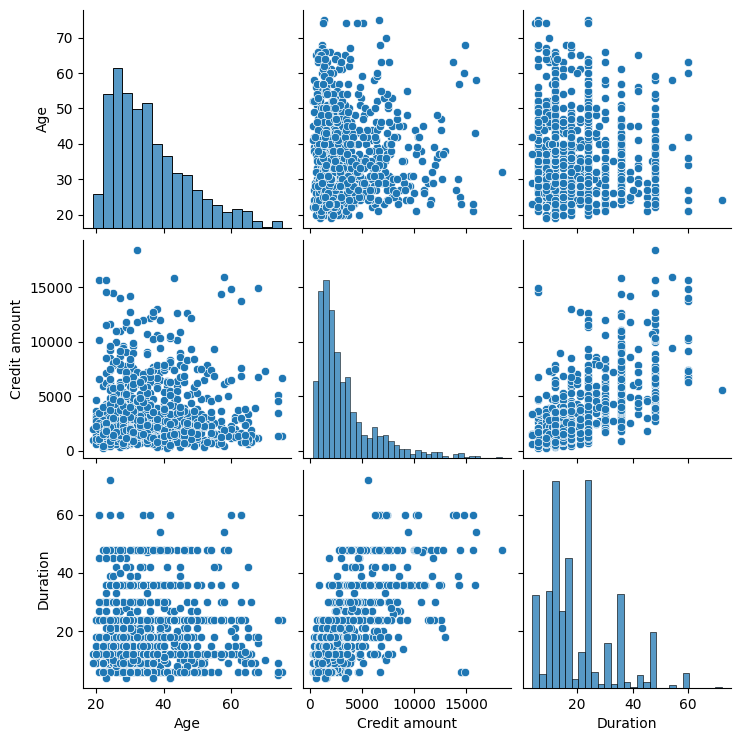

In [3505]:
sns.pairplot(data = df_analise[numericas]);

Podemos observar que pelo gráfico de disperção, pode haver relação linear entre as variáveis credit amount e duration. Isso faz sentido e até explica o comportamento similar entre essas features quando avaliadas agrupadas pela variável dependente, pois quanto maior o empréstimo, mais tempo o cliente tem para pagar. Para ratificar nossa hipótese, vamos plotar o mapa de calor das correlações lineares entre as variáveis.

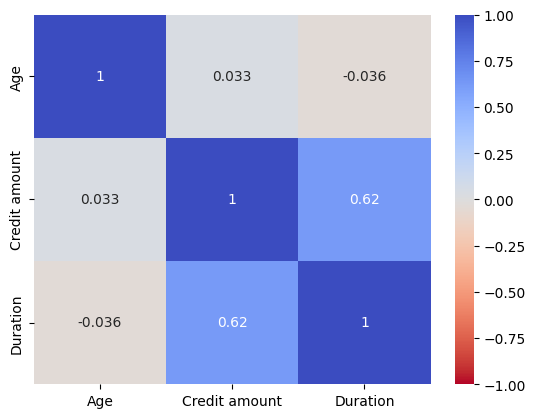

In [3506]:
corr = df_analise[numericas].corr()

sns.heatmap(data = corr , vmin = -1 , vmax = 1 , cmap = 'coolwarm_r' , annot = True);

Como era esperado, o heatmap indica forte relação linear entre as features credit amount e duration.

# Plot das variáveis categóricas

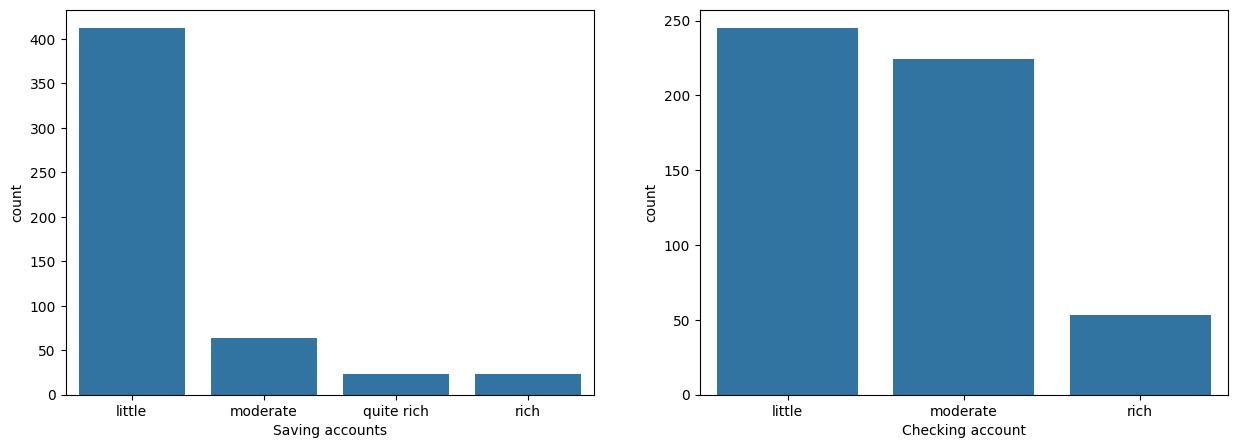

In [3507]:
fig , ax = plt.subplots(figsize = (15 , 5) , nrows = 1 , ncols = 2)

compair = df_dados.dropna()

sns.barplot(y = compair['Saving accounts'].value_counts() , x = compair['Saving accounts'].value_counts().index 
            , ax = ax[0])

sns.barplot(y = compair['Checking account'].value_counts() , x = compair['Checking account'].value_counts().index 
            , ax = ax[1])

plt.show()

Plotamos a distribuição das features que preenchemos. Vamos avaliar se houve diferença na dstribuição das variáveis.

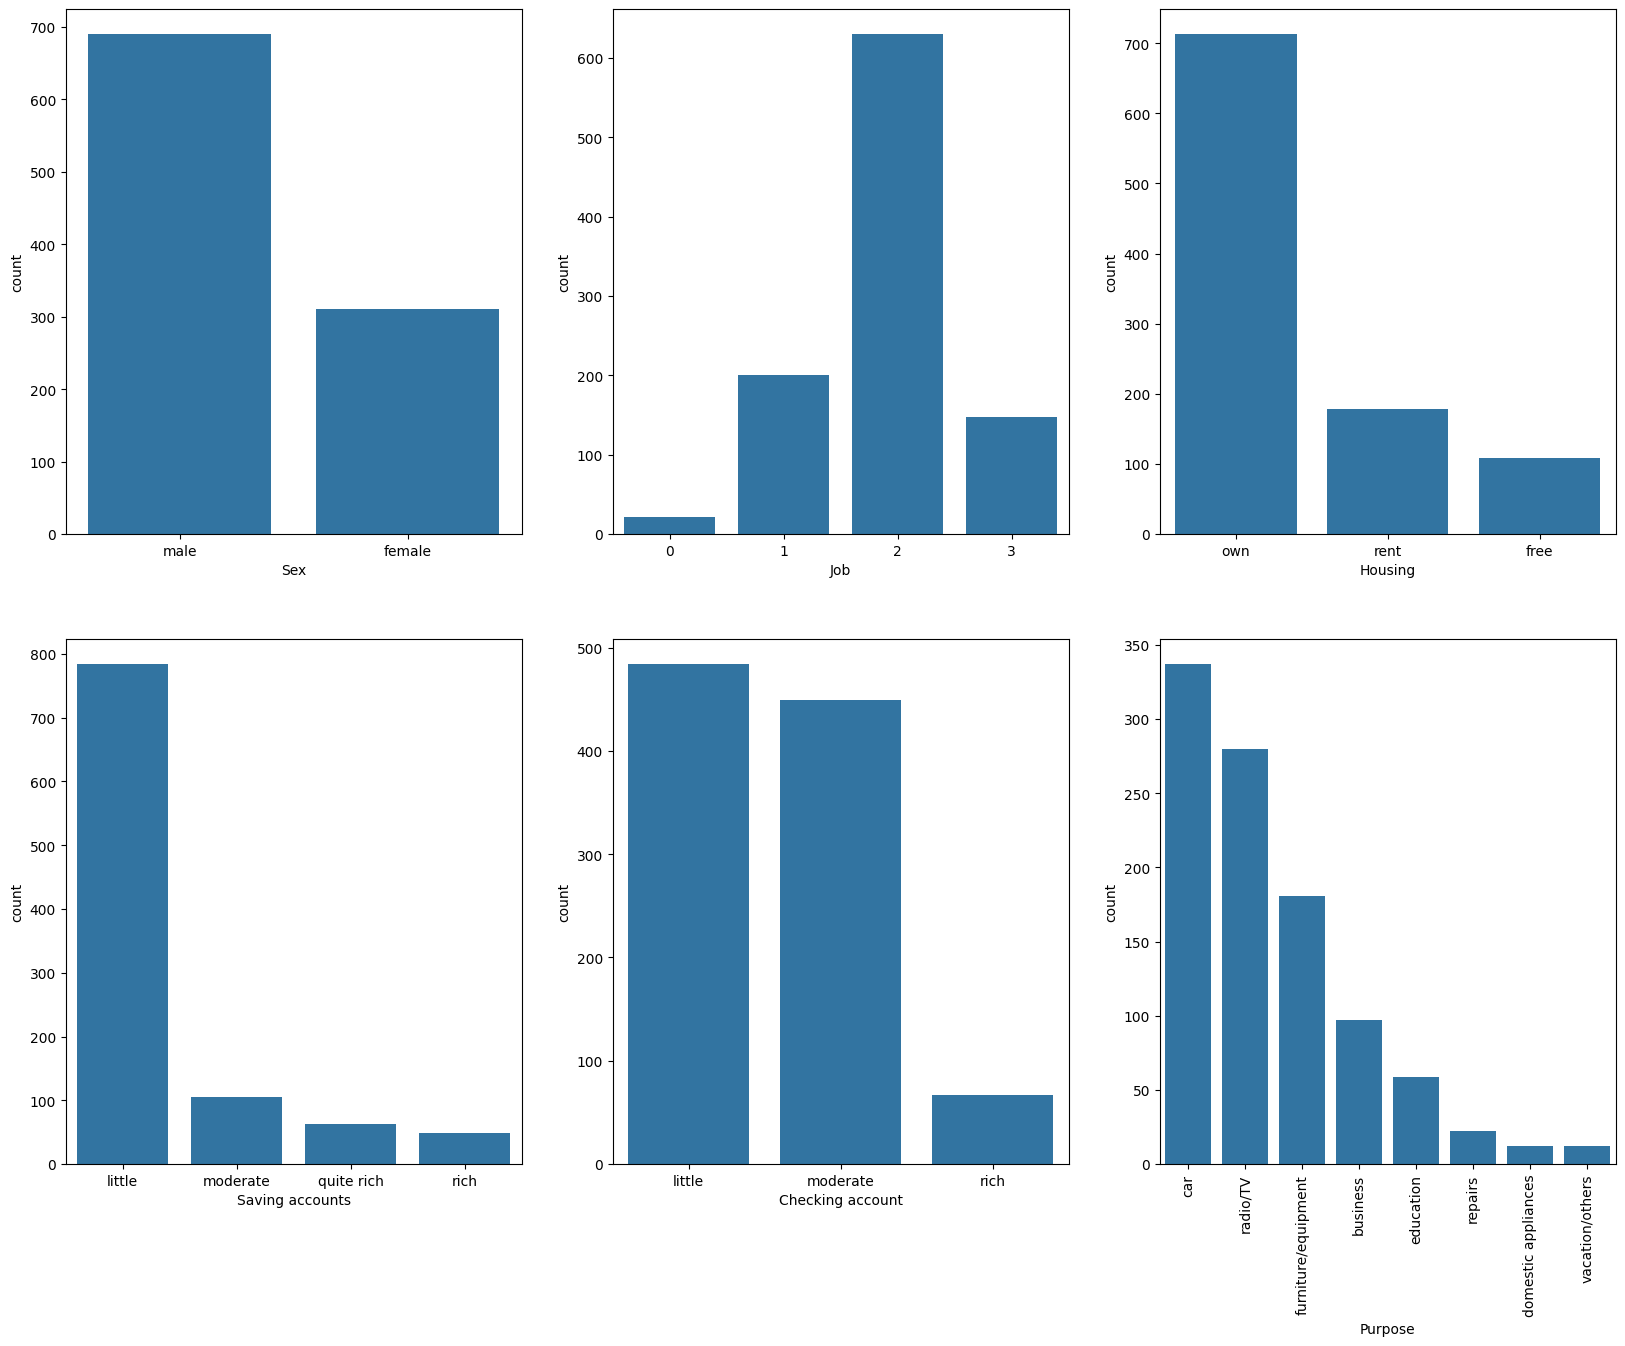

In [3508]:
fig , ax = plt.subplots(figsize = (20 , 15) , nrows = 2 , ncols = 3)

for i , coluna in enumerate(categoricas):
    sns.barplot( x = df_analise[coluna].value_counts().index , y = df_analise[coluna].value_counts() , ax = ax[i // 3][i % 3])

ax[1][2].tick_params(axis = 'x' , rotation = 90)
    
plt.show() 

Como podemos ver, maior parte tem avaliação baixa no valor da conta poupança. Já a avaliação da conta corrente, temos muitos valores moderados também. Pela dstribuição antes e depois de tratar os valores faltantes, não parece haver grande diferença, indicando que o modelo de previsão ajustou bem os dados. Vamos agora avaliar como cada variável categórica se comporta indexada pela avaliação de crédito. 

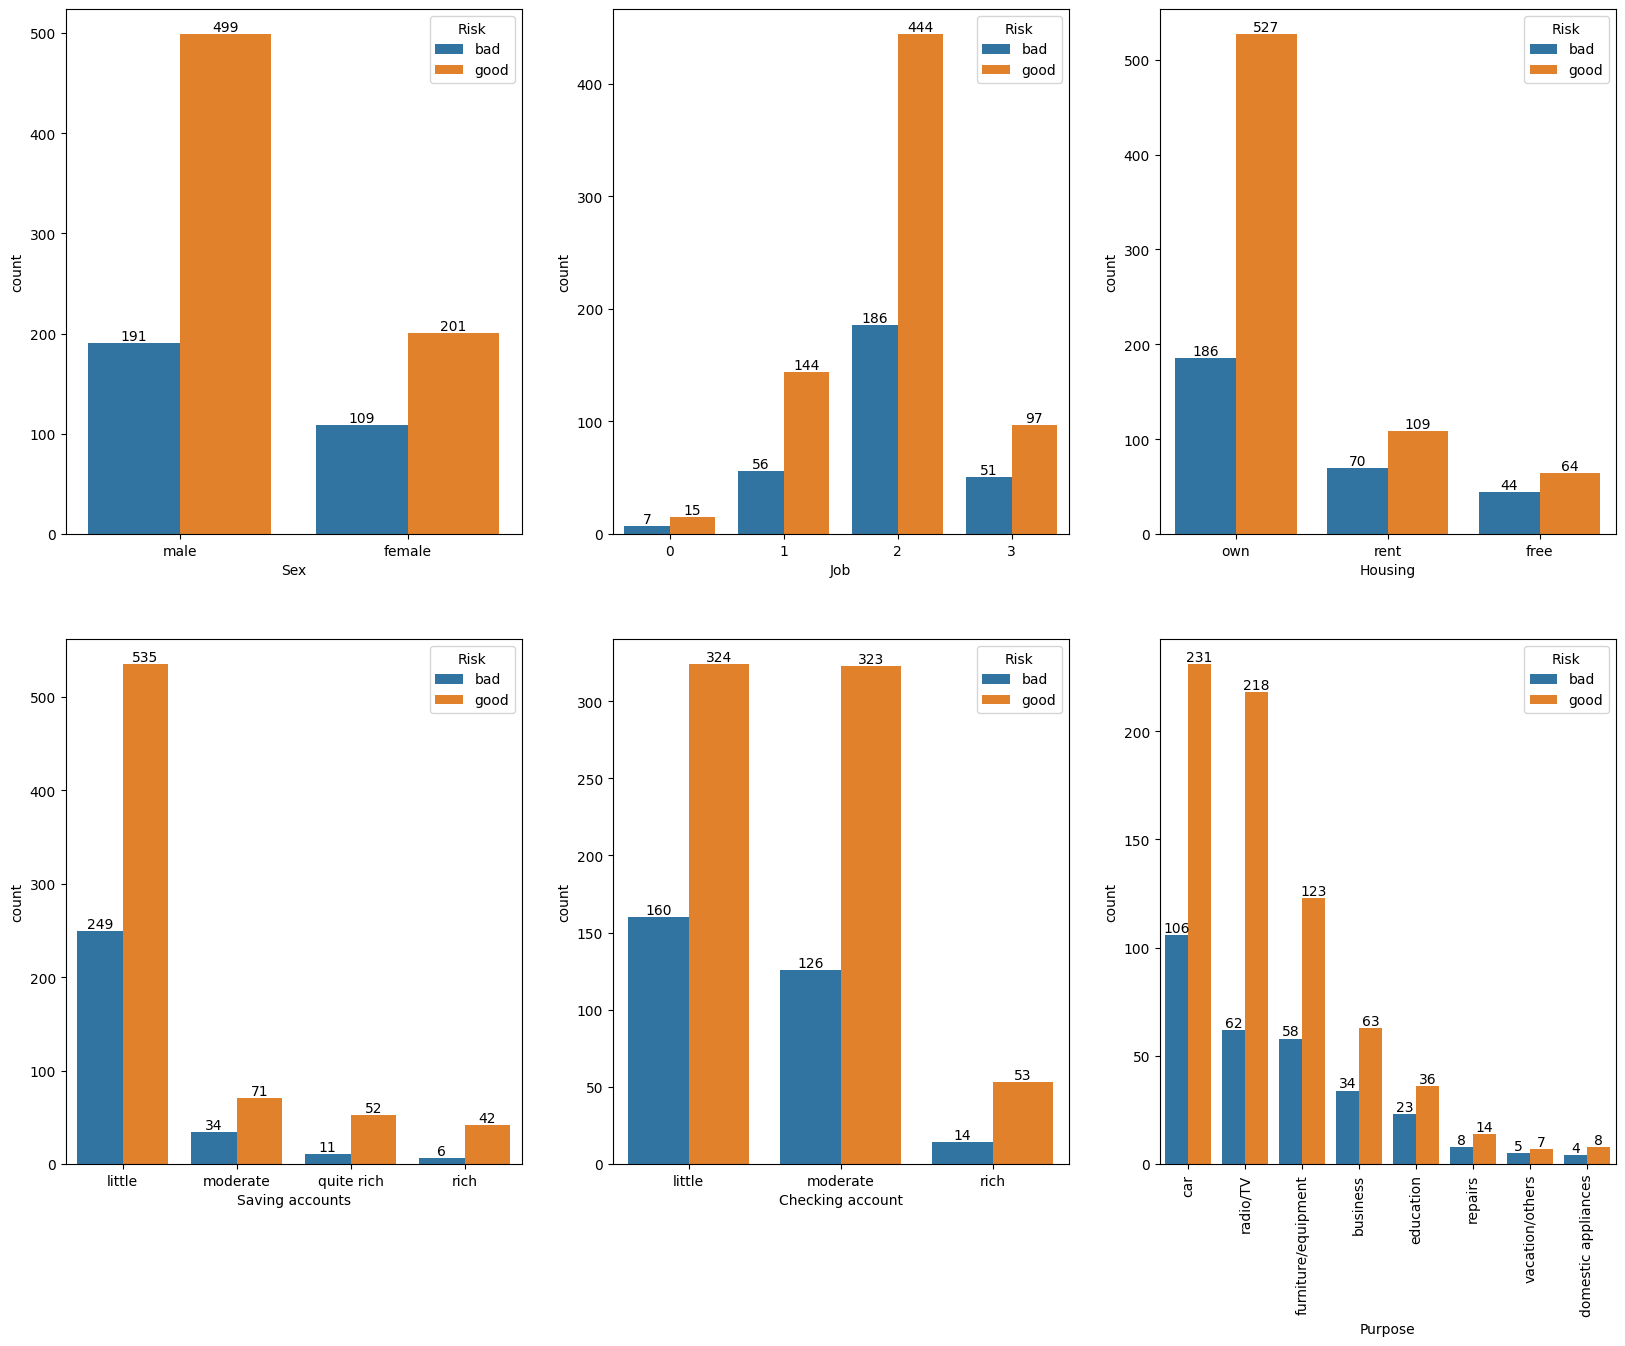

In [3509]:
fig , ax = plt.subplots(figsize = (20 , 15) , nrows = 2 , ncols = 3)

for i , coluna in enumerate(categoricas):
    df_agrupado = pd.DataFrame(df_analise[[coluna , 'Risk']].groupby('Risk').value_counts())
    barra = sns.barplot(data = df_agrupado ,x = coluna , y = 'count'  , ax = ax[i // 3][i % 3] , hue = 'Risk' , )
    for container in barra.containers:
        labels = [f"{v.get_height():.0f}" for v in container]
        ax[i // 3][i % 3].bar_label(container) 

ax[1][2].tick_params(axis = 'x' , rotation = 90)
    
plt.show()

A coluna Sex indica uma leve diferença no perfil de avaliação entre homens e mulheres. Na coluna Job, as categorias 1 e 2 parecem apresentar melhores perfis de pagadores. Outra diferença é no tipo de moradia. Os dados mostram que pessoas que possuem casa própria possuem melhor perfil do que pessoas que moram de aluguel ou moradia gratuita. Já os dados financeiros indicam que quanto melhor a avaliação da contas bancárias, melhor a avaliação de crédito. Já observando os motivos de emprestimo, precisamos fazer uma análise mais profunda: Vamos avaliar como o motivo do emprestimo tem relação com o quanto foi emprestado e claro com a duração. Podemos observar previamente que entre aqueles que pediram emprestimo para radio/Tv possui melhor perfil de crédito, percentualmente, enquanto repairs e education tem piores avaliações. O restante das categorias possuem percentual intermediário. Era esperado que categorias mais caras como carros tivessem piores pagadores, pela amostra de credit amount que vimos no plot das variáveis numéricas. Para avaliar melhor essa questão, vamos avaliar como as variáveis Purpose e credit amount se comportam entre si.


# Análise mista entre variáveis categóricas e numéricas

In [3510]:
df = df_analise[['Purpose' , 'Credit amount']].groupby('Purpose' , as_index = False).mean().sort_values(by = 'Credit amount' , ascending = False)
display(df_analise['Purpose'].value_counts())
display(df)

Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

,Purpose,Credit amount
7,vacation/others,8209.333333
0,business,4158.041237
1,car,3768.192878
4,furniture/equipment,3066.988950
3,education,2879.203390
6,repairs,2728.090909
5,radio/TV,2487.653571
2,domestic appliances,1498.000000


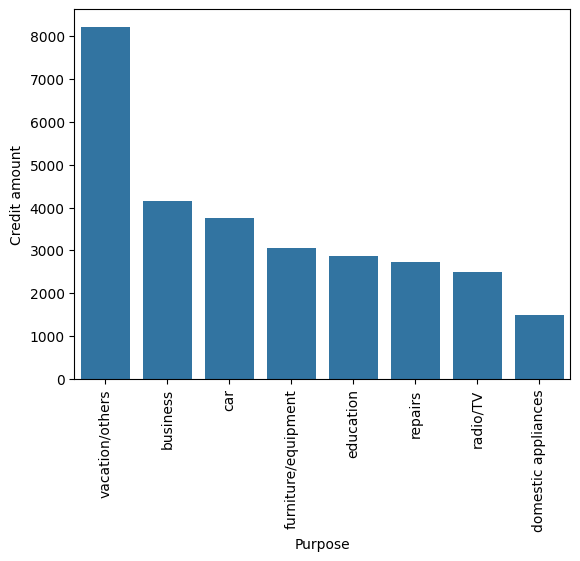

In [3511]:
fig, ax = plt.subplots()
sns.barplot(x = df['Purpose'], y = df['Credit amount'], ax = ax)
ax.tick_params(axis = 'x' , rotation = 90)
plt.show()

Avaliando cada categoria de purpose, podemos observar que a variável vacation/other, que possui o maior valor médio emprestado disparado. Isso justifica o fato de ser uma categoria com bom percentual de maus pagadores, pois como vimos, a avaliação de crédito costuma variar negativamente quanto maior o valor do emprestimo. business, o segundo maior valor médio, possui percentual intermediário de bons pagadores. A variável car segue a mesma lógica, possuindo uma média de valor um pouco mais barata, com um percentual um pouco melhor na avaliação. A feature furniture também segue uma lógica semelhante. Quanto às variáveis eduaction, repairs e domestic appliance que possuem médias de empréstimo mais baixa em comparação com as demais, tem um comportamento inverso, apresentando maior percentual de maus pagadores, mesmo tendo a média do valor mais baixa. Já a variável radio/Tv segue o comportamento esperado, onde é a segunda média mais barata de utilitários, com o melhor percentual de bons pagadores nas avaliações. Vamos investigar por que utilitários com emprestimo médio em valores tão baixos podem apresentar percentual tão alto de maus pagadores. Um palpite inicial seria de que pessoas com status da conta corrente e poupança mais baixos, que inclusive vimos que possuem mais dificuldade de pagar o emprestimo, pedem emprestimo para pagar necessidades mais básicas, como financiar a eduacação, reparos e utensílios domésticos, enquanto pessoas com melhor condição, e portanto melhores pagadores, pedem emprestimos para utensílios mais caros e mesmo assim conseguem pagar, pela condição. Por isso, vamos investigar como a variável Checking account, está ligada com a variável Purpose. 

In [3512]:
df = pd.DataFrame(df_analise[['Purpose' , 'Checking account']].groupby('Checking account').value_counts()).reset_index()

display(df)

,Checking account,Purpose,count
0,little,car,198
1,little,furniture/equipment,118
2,little,radio/TV,100
3,little,education,27
4,little,business,22
5,little,repairs,8
6,little,domestic appliances,7
7,little,vacation/others,4
8,moderate,radio/TV,154
9,moderate,car,120


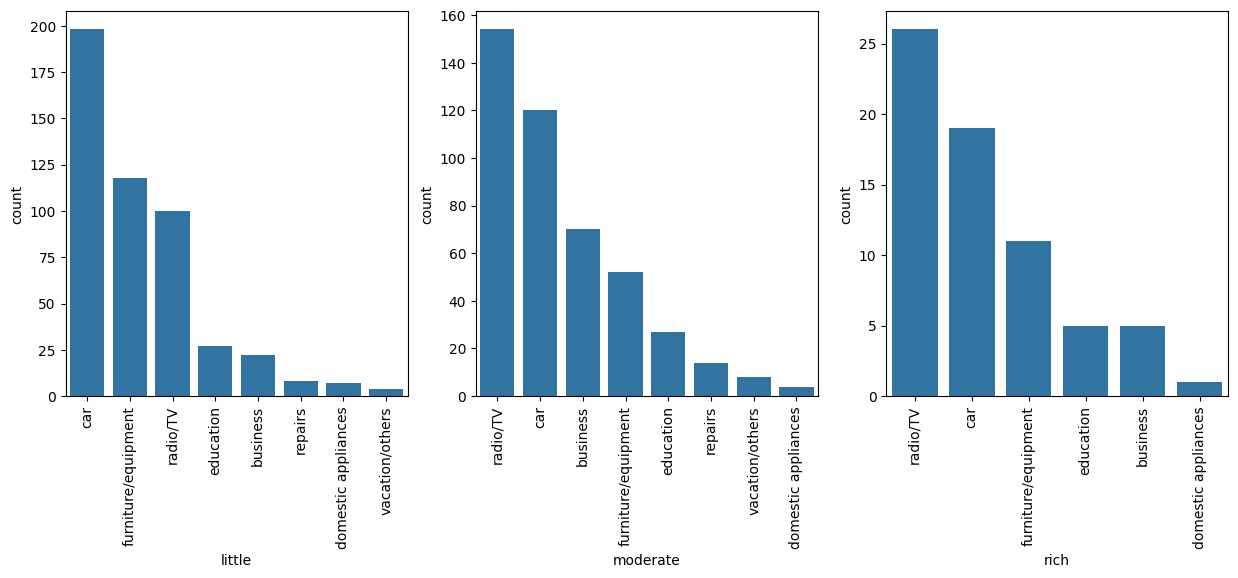

In [3513]:
fig, ax = plt.subplots(figsize = (15 , 5) , nrows = 1 , ncols = 3)

for i , coluna in enumerate(df['Checking account'].unique().tolist()):
    sns.barplot(data = df[df['Checking account'] == coluna] , x = 'Purpose' , y = 'count', ax = ax[i])
    ax[i].tick_params(axis = 'x' , rotation = 90)
    ax[i].set_xlabel(coluna)

plt.show()

Podemos perceber que nenhuma das pessoas da classe alta posssui emprestimo por motivos de férias e nem de reparos. Além disso, poucas pessoas dessa classe pedem emprestimo por motivos de educação ou aplicações domésticas, mostrando que pessoas dessa classe não costumam precisar de financiamento para essas necessidades básicas. Em contrapartida, na classe baixa podemos observar que educação aparece em quarto na ordem de motivos de financiamento. Analisando a classe média, business está em terceiro na ordem do financiamento, diferentemente das outras classes, podendo representar uma classe com muitos microempreendedores. As demais variáveis seguem uma ordem um tano quanto parecida nas prioridade de financiamento. Essa analise confirma nossas desconfiança de que as pessoas de classes mais baixas também precisam de emprestimo para necessidade mais básicas, com algumas esseções como furniture e car que possuem média de valor de financiamento alta, e todas as classes usam emprestimos para esses utilitários.

# Criando nossos modelos de predição

Para nosso problema de classificação de avaliação de crédito, vamos usar modelos de regressão Linear, Random Forest Classifier e Extra Trees Classifier. Para avaliar a bondade do ajuste, vamos implementar a matriz de confusão e futuramente, vamos avaliar que métricas podemos avaliar, tendo em vista que dar boa avaliação para maus pagadores é prejudicial para o banco e o dar avaliação ruim para bons pagadores também é ruim, pois pode causar a perda de um bom cliente. A função de perda que vamos utilizar é a entropia cruzada, útil em problemas de classificação. Vamos implementar para visualização a curva AUC-ROC e utilizar o critério AIC para penalização no número de features. Para modelos de regressão logística, vamo avaliar os p-valores para avaliar a relevância de cada feature para a variável dependente, bem como as importâncias nos modelos de Random Forest e Extra Trees.

In [3514]:
df_analise = df_analise.rename({'Saving accounts' : 'Saving_accounts' , 'Checking account' : 'Checking_account' , 'Credit amount' : 'Credit_amount'} , axis = 1)
print(df_analise.columns)

y , X = dmatrices('Risk ~ Age + Sex + Job + Housing + Saving_accounts + Checking_account + Credit_amount + Duration + Purpose' 
                  , data = df_analise , return_type= 'dataframe' )

y = y.drop(['Risk[good]'] , axis = 1)


Index(['Age', 'Sex', 'Job', 'Housing', 'Saving_accounts', 'Checking_account',
       'Credit_amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')


In [3515]:
display(X)

,Intercept,Sex[T.male],Job[T.1],Job[T.2],Job[T.3],Housing[T.own],Housing[T.rent],Saving_accounts[T.moderate],Saving_accounts[T.quite rich],Saving_accounts[T.rich],...,Purpose[T.car],Purpose[T.domestic appliances],Purpose[T.education],Purpose[T.furniture/equipment],Purpose[T.radio/TV],Purpose[T.repairs],Purpose[T.vacation/others],Age,Credit_amount,Duration
0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,67.0,1169.0,6.0
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,22.0,5951.0,48.0
2,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,49.0,2096.0,12.0
3,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,45.0,7882.0,42.0
4,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,4870.0,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,31.0,1736.0,12.0
996,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,3857.0,30.0
997,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,38.0,804.0,12.0
998,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,23.0,1845.0,45.0


# Modelo de Regressão Logística

In [3516]:
modelo_lr = sm.Logit(y , X)
res = modelo_lr.fit()
print(res.summary2())

Optimization terminated successfully.
         Current function value: 0.561379
         Iterations 6
                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      Risk[bad]            Pseudo R-squared:     0.081     
Date:                    2026-04-16 20:07     AIC:                  1166.7588 
No. Observations:        1000                 BIC:                  1274.7294 
Df Model:                21                   Log-Likelihood:       -561.38   
Df Residuals:            978                  LL-Null:              -610.86   
Converged:               1.0000               LLR p-value:          4.3882e-12
No. Iterations:          6.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                                Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-------------------------------------------------------------

In [3517]:
p_values = res.pvalues.sort_values()
entropia_cruzada = -res.llf / res.nobs
print(f"A perda é {entropia_cruzada}")
print(p_values)

A perda é 0.5613794075380593
Duration                          0.000002
Age                               0.009157
Saving_accounts[T.rich]           0.019069
Sex[T.male]                       0.035361
Checking_account[T.moderate]      0.043748
Saving_accounts[T.quite rich]     0.062504
Housing[T.own]                    0.067970
Purpose[T.radio/TV]               0.082390
Checking_account[T.rich]          0.196360
Purpose[T.repairs]                0.454472
Purpose[T.education]              0.474767
Purpose[T.car]                    0.664129
Purpose[T.furniture/equipment]    0.681117
Credit_amount                     0.744839
Job[T.2]                          0.758033
Purpose[T.domestic appliances]    0.872068
Purpose[T.vacation/others]        0.892026
Saving_accounts[T.moderate]       0.897674
Job[T.3]                          0.930512
Housing[T.rent]                   0.937314
Intercept                         0.947075
Job[T.1]                          0.961226
dtype: float64


Podemos ver que acima o resultado do nosso primeiro modelo. Vamos usar os p-values acima para pegar as variáveis com maior relevância que são duration, age, sex e Saving accounts e implementar nosso modelo considerando apenas essas variáveis. Vamos considerar também housing e purpose, pois a categoria dummie radio/Tv se destacou das demais. Isso provavelmente deve diminuir o AIC, critério que penaliza o número de features independentes.  

In [3518]:
lista = p_values.index.tolist()
print(lista)
X = X[['Duration', 'Age', 'Saving_accounts[T.rich]', 'Sex[T.male]', 'Saving_accounts[T.quite rich]', 'Housing[T.own]', 'Purpose[T.radio/TV]',
       'Purpose[T.education]', 'Purpose[T.repairs]', 'Purpose[T.car]', 'Purpose[T.furniture/equipment]' , 'Saving_accounts[T.moderate]', 'Purpose[T.domestic appliances]',
       'Purpose[T.vacation/others]', 'Housing[T.rent]']]

['Duration', 'Age', 'Saving_accounts[T.rich]', 'Sex[T.male]', 'Checking_account[T.moderate]', 'Saving_accounts[T.quite rich]', 'Housing[T.own]', 'Purpose[T.radio/TV]', 'Checking_account[T.rich]', 'Purpose[T.repairs]', 'Purpose[T.education]', 'Purpose[T.car]', 'Purpose[T.furniture/equipment]', 'Credit_amount', 'Job[T.2]', 'Purpose[T.domestic appliances]', 'Purpose[T.vacation/others]', 'Saving_accounts[T.moderate]', 'Job[T.3]', 'Housing[T.rent]', 'Intercept', 'Job[T.1]']


In [3519]:
logit_atualizada = sm.Logit(y , X)
res = logit_atualizada.fit()
print(res.summary2())

Optimization terminated successfully.
         Current function value: 0.564271
         Iterations 6
                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      Risk[bad]            Pseudo R-squared:     0.076     
Date:                    2026-04-16 20:07     AIC:                  1158.5426 
No. Observations:        1000                 BIC:                  1232.1589 
Df Model:                14                   Log-Likelihood:       -564.27   
Df Residuals:            985                  LL-Null:              -610.86   
Converged:               1.0000               LLR p-value:          9.4596e-14
No. Iterations:          6.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                                Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-------------------------------------------------------------

In [3520]:
p_values = res.pvalues.sort_values()
print(p_values)
loss = -res.llf/res.nobs
print(f"A log perda é {loss}")

Duration                          1.534444e-10
Age                               4.286640e-04
Housing[T.own]                    2.606475e-03
Saving_accounts[T.rich]           1.230793e-02
Purpose[T.radio/TV]               2.277763e-02
Sex[T.male]                       2.429001e-02
Saving_accounts[T.quite rich]     4.694255e-02
Purpose[T.repairs]                4.744233e-01
Purpose[T.education]              5.117099e-01
Housing[T.rent]                   6.217789e-01
Saving_accounts[T.moderate]       6.280663e-01
Purpose[T.car]                    7.081340e-01
Purpose[T.furniture/equipment]    7.096349e-01
Purpose[T.domestic appliances]    8.863875e-01
Purpose[T.vacation/others]        9.612415e-01
dtype: float64
A log perda é 0.5642712834670822


O modelo obteve métricas discrtamente melhores em comparação com o outro modelo, por exemplo o AIC um pouco menor. Vamos agora usar Scikit learn para implementar a matriz de confusão e a curva AUC-ROC.  

In [3521]:
print(categoricas)

X = df_analise
X = X.rename({'Saving_accounts' : 'Saving accounts' , 'Checking_account' : 'Checking account' , 'Credit_amount' : 'Credit amount'}, axis = 1)
df_analise = X 
y = X['Risk']
X = X.drop(['Risk'] , axis = 1)

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']


In [3522]:
X = X.rename({'Saving_accounts' : 'Saving accounts' , 'Checking_account' : 'Checking account' , 'Credit_amount' : 'Credit amount'}, axis = 1)
print(X.columns)

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose'],
      dtype='str')


In [3523]:
ohe = OneHotEncoder( sparse_output = False , handle_unknown = 'ignore' , drop = 'if_binary')

colunas_transformadas = ohe.fit_transform(X[categoricas])

df_ohe = pd.DataFrame(colunas_transformadas , index = X.index , columns = ohe.get_feature_names_out())

X = pd.concat([df_analise.drop(categoricas , axis = 1) , df_ohe] , axis = 1)

display(X)

,Age,Credit amount,Duration,Risk,Sex_male,Job_0,Job_1,Job_2,Job_3,Housing_free,...,Checking account_moderate,Checking account_rich,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,1169,6,good,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,22,5951,48,bad,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,49,2096,12,good,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,45,7882,42,good,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,53,4870,24,bad,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,1736,12,good,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
996,40,3857,30,good,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
997,38,804,12,good,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
998,23,1845,45,bad,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [3524]:
dic = {'good' : 1 , 'bad' : 0}


In [3525]:
X_train , X_test , y_train , y_test = train_test_split(X, y , random_state= 42 , test_size= 0.3)
y_train = y_train.replace(dic).astype(int)
y_test = y_test.replace(dic).astype(int)
X_train = X_train.drop(['Risk'] , axis = 1)
X_test = X_test.drop(['Risk'] , axis = 1)

modelo_lr = LogisticRegression(random_state = 42)
modelo_lr.fit(X_train , y_train)
y_pred = modelo_lr.predict(X_test)


c:\Users\vitor\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Positivo,Negativo
Positivo,17,74
Negativo,23,186


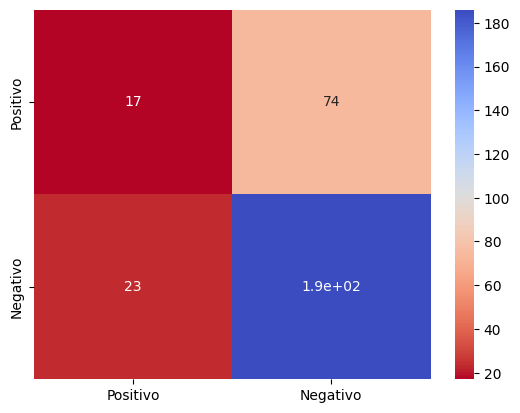

In [3526]:
confusao = pd.DataFrame(confusion_matrix(y_test, y_pred) , index = ['Positivo' , 'Negativo'], columns = ['Positivo' , 'Negativo'])
display(confusao)

sns.heatmap(data = confusao , cmap= 'coolwarm_r' , annot = True );



Usando a matriz de confusão para avaliar as métricas de bondade do ajuste 

In [3527]:
report = pd.DataFrame(classification_report(y_test , y_pred , output_dict= True))
print(report)

                   0           1  accuracy   macro avg  weighted avg
precision   0.425000    0.715385  0.676667    0.570192      0.627301
recall      0.186813    0.889952  0.676667    0.538383      0.676667
f1-score    0.259542    0.793177  0.676667    0.526359      0.631308
support    91.000000  209.000000  0.676667  300.000000    300.000000


A precisão indica quanto do total de classificados como uma certa classe eram realmente daquela classe. Podemos ver que para os classificados como negativo, ou seja, baixo risco de crédito, a acurácia foi de 88%. Ou seja dos classificados com baixo risco de crédito, 88% realmente possuia baixo risco de crédito. Porém, entre as pessoas classificadas com risco alto de crédito, somente 18% possuia alto risco realmente. Isso pode acontecer devido ao desbalanço do modelo, ou porque o modelo linear pode não se ajustar tão bem aos dados. Vamos realizar um outro teste com esse modelo utilizando um novo valor de cutoff. Por outro lado, o recall mede de uma certa classe realmente foram classificados na mesma. Por exemplo, entre as pessoas que possuiam risco alto, 41% foram classificadas corretamente. Isso indica que muitas pessoas com alto risco de credito foram classificadas incorretamente, o que não é bom para um modelo de análise de crédito. Já na classe com baixo risco, vemos um recall de 79%, indicando que 79% das pessoas com baixo risco foi corretamente classificada. O f1 score mede a média harmônica entre recall e precisão e a acurácia mede o percentual de classificações corretas. 68% das pessoas foram corretamente classificadas de acordo com nosso modelo. Com isso, vamos construir outro modelo ajustado com um novo valor de cutoff. Para isso, vamos usar a curva Roc para avaliar que valor podemos utilizar.

In [3528]:
y_probs = modelo_lr.predict_proba(X_test)[: , 1]
auc = roc_auc_score(y_test , y_probs)

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

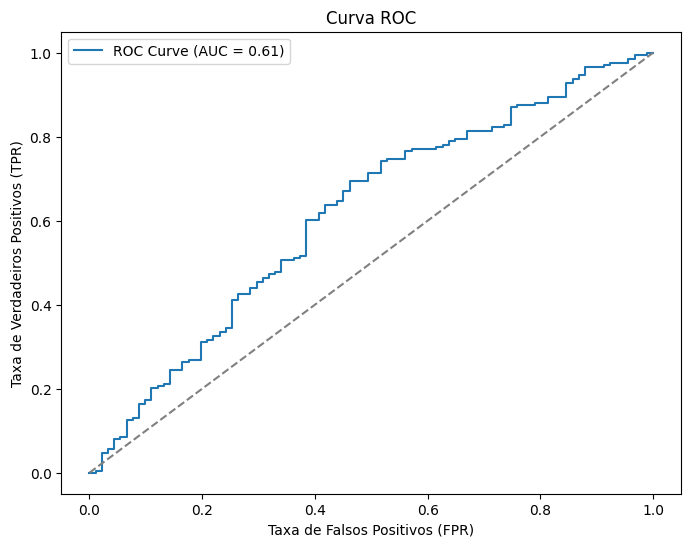

In [3529]:
fig , ax = plt.subplots(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')

plt.legend()
plt.show()

Observe que que a curva ROC mostra que se aumentarmos muito o limiar de decisão para aumentar a taxa de verdadeiros positivos, ou seja, o percentual pessoas com risco de crédito alto classificadas corretamente, isso aumentaria muito a taxa de pessoas com baixo risco de crédito classificadas errôneamente como com risco alto. Isso pode acontecer pelo desbalanço entre as classes da variável alvo. Por isso, vamos avaliar a curva Precision-Recall, que é ideal para a situação com dados desbalanceados.

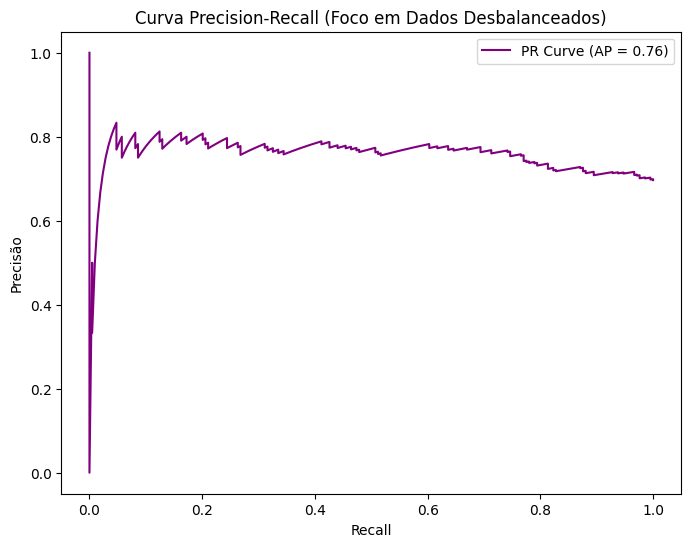

In [3530]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

ap_score = average_precision_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', label=f'PR Curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva Precision-Recall (Foco em Dados Desbalanceados)')
plt.legend()

plt.show()

In [3531]:
y_pred = np.where(y_probs > 0.5 , 1 , 0)

print(pd.DataFrame(classification_report(y_test , y_pred ,output_dict= True)))

y_pred = np.where(y_probs > 0.6 , 1 , 0)

print(pd.DataFrame(classification_report(y_test , y_pred ,output_dict= True)))

y_pred = np.where(y_probs > 0.65 , 1 , 0)

print(pd.DataFrame(classification_report(y_test , y_pred ,output_dict= True)))

                   0           1  accuracy   macro avg  weighted avg
precision   0.425000    0.715385  0.676667    0.570192      0.627301
recall      0.186813    0.889952  0.676667    0.538383      0.676667
f1-score    0.259542    0.793177  0.676667    0.526359      0.631308
support    91.000000  209.000000  0.676667  300.000000    300.000000
                   0           1  accuracy   macro avg  weighted avg
precision   0.422535    0.733624      0.66    0.578080      0.639261
recall      0.329670    0.803828      0.66    0.566749      0.660000
f1-score    0.370370    0.767123      0.66    0.568747      0.646775
support    91.000000  209.000000      0.66  300.000000    300.000000
                   0           1  accuracy   macro avg  weighted avg
precision   0.430108    0.753623  0.653333    0.591865      0.655490
recall      0.439560    0.746411  0.653333    0.592986      0.653333
f1-score    0.434783    0.750000  0.653333    0.592391      0.654384
support    91.000000  209.000000  

Avaliando as curvas acima, e tendo em vista que maus pagadores classificado como bons são prejuízos potênciais, o modelo utilizando limiar de ajuste de 0.55 parace ser o mais adequado para o modelo. Vamos avaliar a entropia cruzada do nosso modelo de regressão logística. 

In [3532]:
y_pred = np.where(y_probs > 0.55 , 1 , 0)
entropia_cruzada = log_loss(y_pred , y_test)
print(f'A entropia cruzada do modelo é de {entropia_cruzada:.4f}')


A entropia cruzada do modelo é de 12.1347


Com isso, podemos partir para a criação do nosso próximo modelo

# Random Forest Classifier 

In [3533]:
modelo_rf = RandomForestClassifier(random_state= 42)
modelo_rf.fit(X_train , y_train)
y_pred = modelo_rf.predict(X_test)

,Positive,Negative
Positive,25,66
Negative,20,189


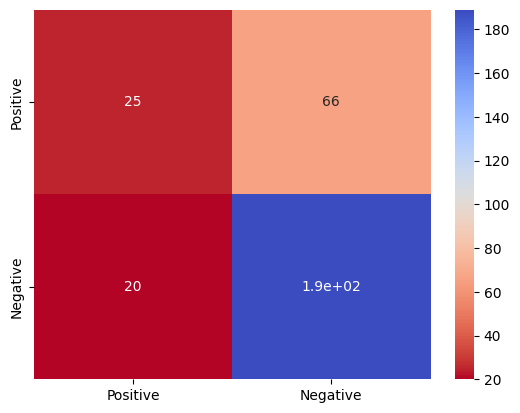

In [3534]:
matriz = pd.DataFrame(confusion_matrix(y_test , y_pred) , index = ['Positive' , 'Negative'] , columns = ['Positive' , 'Negative'])
display(matriz)

sns.heatmap(data = matriz, cmap= 'coolwarm_r' , annot = True );


In [3535]:
print(pd.DataFrame(classification_report(y_test , y_pred, output_dict= True)))
print(roc_auc_score(y_test , y_pred))

                   0           1  accuracy   macro avg  weighted avg
precision   0.555556    0.741176  0.713333    0.648366      0.684871
recall      0.274725    0.904306  0.713333    0.589516      0.713333
f1-score    0.367647    0.814655  0.713333    0.591151      0.679063
support    91.000000  209.000000  0.713333  300.000000    300.000000
0.5895157474104842


Podemos ver que o modelo de Random Forest obteve métricas um pouco melhores que o modelo de Regressão logística mesmo com limiar de decisão de 0.5, mas mesmo com auc_score melhor, ainda está baixo. Isso pode indicar overfitting. Vamos avaliar um diagnóstico mas desta vez com dados de treino. Se as métricas forem muito melhores, temos um overffiting. 


In [3536]:
y_val = modelo_rf.predict(X_train)
print(pd.DataFrame(classification_report(y_val , y_train , output_dict= True)))

               0      1  accuracy  macro avg  weighted avg
precision    1.0    1.0       1.0        1.0           1.0
recall       1.0    1.0       1.0        1.0           1.0
f1-score     1.0    1.0       1.0        1.0           1.0
support    209.0  491.0       1.0      700.0         700.0


In [3537]:
y_val = modelo_lr.predict(X_train)
print(pd.DataFrame(classification_report(y_val , y_train , output_dict= True)))

                   0           1  accuracy   macro avg  weighted avg
precision   0.253589    0.926680  0.725714    0.590134      0.841101
recall      0.595506    0.744681  0.725714    0.670093      0.725714
f1-score    0.355705    0.825771  0.725714    0.590738      0.766006
support    89.000000  611.000000  0.725714  700.000000    700.000000


Acima podemos ver um overfitting severo no modelo random Forest. Para ajustar isso, vamos limitar a profundidade máxima da árvore. 

In [3538]:
y_probs = modelo_rf.predict_proba(X_test)[: , 1]

auc = roc_auc_score(y_test , y_probs)

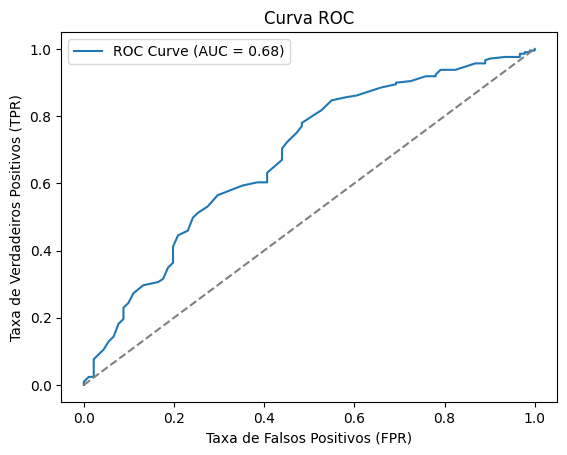

In [3539]:
tpr , fpr , thresholds = roc_curve(y_test , y_probs)

fig , ax = plt.subplots()
ax.plot(tpr , fpr , label=f'ROC Curve (AUC = {auc:.2f})')
ax.plot([0 , 1] ,[0 , 1] , linestyle = '--' , color = 'gray')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')

plt.legend()
plt.show()

In [3540]:
loss = log_loss(y_test , y_pred)
print(f'A entropia cruzada é {loss:.4f}')

A entropia cruzada é 10.3325


Diferentemente da regressão logística, temos um clássico caso de overfitting, onde o modelo aprende de maneira muito específica os dados de treino e não consegue ajustar muito bem para o teste e em casos gerais. Para tratar o problema, podemos diminuir o número de variáveis que vamos considerar para nosso modelo, limitar a profundidade máxima da árvore, ou usar validação cruzada, útil em modelos com desbalanço de classes. Primeiro vamos tentar implementar um modelo com limite de altura máxima da árvore.  

# Random Forest (profundidade ajustada e peso nas classes)

In [3541]:
modelo_rf = RandomForestClassifier(max_depth = 8 , random_state = 42 , class_weight = 'balanced')
modelo_rf.fit(X_train , y_train)
y_pred = modelo_rf.predict(X_test)

print(pd.DataFrame(classification_report(y_pred , y_test , output_dict=True)))
y_val = modelo_rf.predict(X_train)
print(pd.DataFrame(classification_report(y_val , y_train , output_dict=True)))
print(roc_auc_score(y_pred , y_test))

                   0           1  accuracy   macro avg  weighted avg
precision   0.351648    0.851675       0.7    0.601661      0.746669
recall      0.507937    0.751055       0.7    0.629496      0.700000
f1-score    0.415584    0.798206       0.7    0.606895      0.717856
support    63.000000  237.000000       0.7  300.000000    300.000000
                    0           1  accuracy   macro avg  weighted avg
precision    0.846890    0.951120      0.92    0.899005      0.921191
recall       0.880597    0.935872      0.92    0.908234      0.920000
f1-score     0.863415    0.943434      0.92    0.903424      0.920457
support    201.000000  499.000000      0.92  700.000000    700.000000
0.6294956801285916


Podemos ver uma pequena melhora escolhendo profundidade máxima igual a 8, porém nada muito relevante. Vamos avaliar agora que features estão influenciando mais para o modelo de random forest.

In [3542]:
importancias = pd.DataFrame(modelo_rf.feature_importances_ , index = X_test.columns , columns = ['importancias'])
display(importancias)

,importancias
Age,0.197399
Credit amount,0.191143
Duration,0.158423
Sex_male,0.031755
Job_0,0.006904
Job_1,0.017090
Job_2,0.020154
Job_3,0.024491
Housing_free,0.024175
Housing_own,0.037914


Todas as features apresentam contribuição relevante

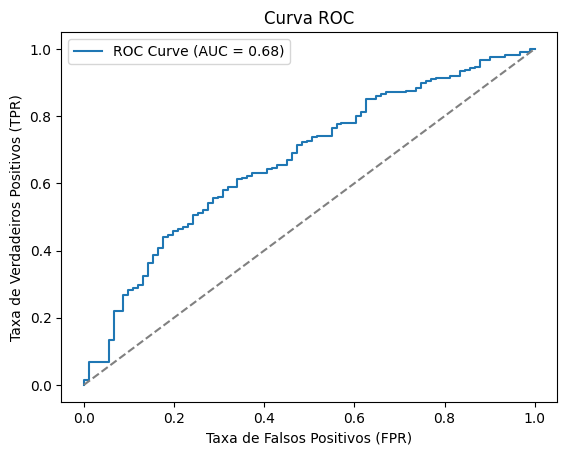

In [3543]:
y_probs = modelo_rf.predict_proba(X_test)[: ,1]
tpr , fpr , thresholds = roc_curve(y_test , y_probs)

fig , ax = plt.subplots()
ax.plot(tpr , fpr , label=f'ROC Curve (AUC = {auc:.2f})')
ax.plot([0 , 1] ,[0 , 1] , linestyle = '--' , color = 'gray')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')

plt.legend()
plt.show()

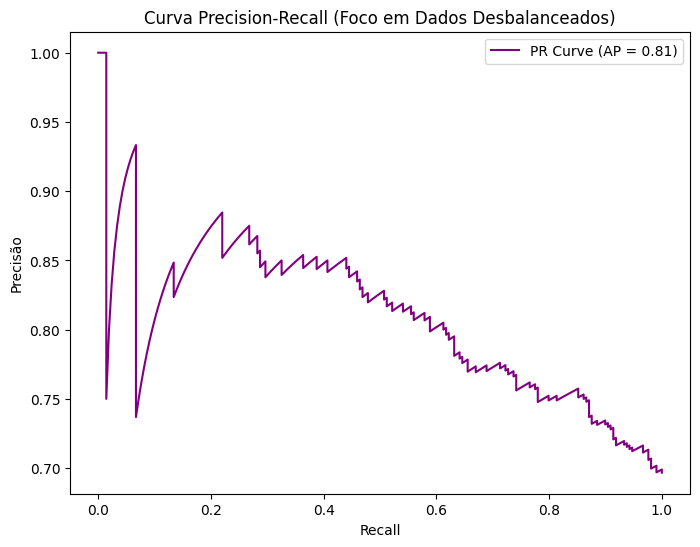

In [3544]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

ap_score = average_precision_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', label=f'PR Curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva Precision-Recall (Foco em Dados Desbalanceados)')
plt.legend()

plt.show()

In [3545]:
y_pred = np.where(y_probs > 0.65, 1 , 0)

print(pd.DataFrame(classification_report(y_test , y_pred ,output_dict= True)))

y_pred = np.where(y_probs > 0.67 , 1 , 0)

print(pd.DataFrame(classification_report(y_test , y_pred ,output_dict= True)))

y_pred = np.where(y_probs > 0.7, 1 , 0)

print(pd.DataFrame(classification_report(y_test , y_pred ,output_dict= True)))

y_pred = np.where(y_probs > 0.75, 1 , 0)

print(pd.DataFrame(classification_report(y_test , y_pred ,output_dict= True)))

                   0           1  accuracy   macro avg  weighted avg
precision   0.397661    0.821705      0.58    0.609683      0.693079
recall      0.747253    0.507177      0.58    0.627215      0.580000
f1-score    0.519084    0.627219      0.58    0.573151      0.594418
support    91.000000  209.000000      0.58  300.000000    300.000000
                   0           1  accuracy   macro avg  weighted avg
precision   0.392473    0.842105  0.563333    0.617289      0.705717
recall      0.802198    0.459330  0.563333    0.630764      0.563333
f1-score    0.527076    0.594427  0.563333    0.560752      0.573997
support    91.000000  209.000000  0.563333  300.000000    300.000000
                   0           1  accuracy   macro avg  weighted avg
precision   0.366197    0.850575  0.506667    0.608386      0.703647
recall      0.857143    0.354067  0.506667    0.605605      0.506667
f1-score    0.513158    0.500000  0.506667    0.506579      0.503991
support    91.000000  209.000000  

# Modelo Extra Trees

In [3546]:
modelo_et = ExtraTreesClassifier(max_depth = 10)
modelo_et.fit(X_train , y_train)
y_pred = modelo_et.predict(X_test)

y_val = modelo_et.predict(X_train)
print(pd.DataFrame(classification_report(y_val , y_train , output_dict=True)))
print(roc_auc_score(y_pred , y_test))

print(pd.DataFrame(classification_report(y_pred , y_test , output_dict=True)))

                    0           1  accuracy   macro avg  weighted avg
precision    0.645933    0.997963  0.892857    0.821948      0.929569
recall       0.992647    0.868794  0.892857    0.930721      0.892857
f1-score     0.782609    0.928910  0.892857    0.855759      0.900486
support    136.000000  564.000000  0.892857  700.000000    700.000000
0.6084558823529411
                   0           1  accuracy   macro avg  weighted avg
precision   0.153846    0.933014  0.696667    0.543430      0.860292
recall      0.500000    0.716912  0.696667    0.608456      0.696667
f1-score    0.235294    0.810811  0.696667    0.523052      0.757096
support    28.000000  272.000000  0.696667  300.000000    300.000000


# Modelo XGBoost 

In [3547]:
modelo_xgb = XGBClassifier()
modelo_xgb.fit(X_train , y_train)
y_pred = modelo_xgb.predict(X_test)
y_probs = modelo_xgb.predict_proba(X_test) [: , 1]
print(pd.DataFrame(classification_report(y_pred , y_test , output_dict=True)))

                   0           1  accuracy   macro avg  weighted avg
precision   0.296703    0.861244      0.69    0.578974      0.755863
recall      0.482143    0.737705      0.69    0.609924      0.690000
f1-score    0.367347    0.794702      0.69    0.581024      0.714929
support    56.000000  244.000000      0.69  300.000000    300.000000


In [3548]:
y_pred = np.where(y_probs > 0.5, 1 , 0)

print(pd.DataFrame(classification_report(y_test , y_pred ,output_dict= True)))

y_pred = np.where(y_probs > 0.65 , 1 , 0)

print(pd.DataFrame(classification_report(y_test , y_pred ,output_dict= True)))

y_pred = np.where(y_probs > 0.75, 1 , 0)

print(pd.DataFrame(classification_report(y_test , y_pred ,output_dict= True)))

                   0           1  accuracy   macro avg  weighted avg
precision   0.482143    0.737705      0.69    0.609924      0.660184
recall      0.296703    0.861244      0.69    0.578974      0.690000
f1-score    0.367347    0.794702      0.69    0.581024      0.665071
support    91.000000  209.000000      0.69  300.000000    300.000000
                   0           1  accuracy   macro avg  weighted avg
precision   0.455696    0.751131  0.673333    0.603414      0.661516
recall      0.395604    0.794258  0.673333    0.594931      0.673333
f1-score    0.423529    0.772093  0.673333    0.597811      0.666362
support    91.000000  209.000000  0.673333  300.000000    300.000000
                   0           1  accuracy   macro avg  weighted avg
precision   0.465347    0.778894  0.673333    0.622121      0.683785
recall      0.516484    0.741627  0.673333    0.629055      0.673333
f1-score    0.489583    0.759804  0.673333    0.624694      0.677837
support    91.000000  209.000000  

Acima podemos ver que implementei vários modelos de árvore e o XGBoost, mas mesmo assim os resultados não foram muito melhores. Vamos experimentar usar SMOTE nos dados de treino para lidar com o desbalanço, e em seguida implementá-lo no random forest, modelo acima que obteve melhores resultados.

# SMOTE

In [3549]:
y = y.replace({'good' : 1 , 'bad' : 0}).astype(int)
display(y)

0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Risk, Length: 1000, dtype: int64

In [3550]:
X = X.drop(['Risk'] , axis = 1)
X_train , X_test, y_train , y_test = train_test_split(X , y , stratify = y , test_size = 0.3) 

display(X_test)

,Age,Credit amount,Duration,Sex_male,Job_0,Job_1,Job_2,Job_3,Housing_free,Housing_own,...,Checking account_moderate,Checking account_rich,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
10,25,1295,12,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
719,31,6148,20,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
407,27,1053,15,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
535,33,2319,21,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
782,31,1410,12,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506,36,2360,15,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
617,37,3676,6,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
849,57,709,12,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
228,22,1478,9,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# Random Forest com SMOTE no treino

In [3551]:
sm = SMOTE()
Xtrain_resampled , ytrain_resampled = sm.fit_resample(X_train , y_train)

modelo_rf.fit(Xtrain_resampled , ytrain_resampled)
y_pred = modelo_rf.predict(X_test)

,Positive,Negative
Positive,20,70
Negative,26,184


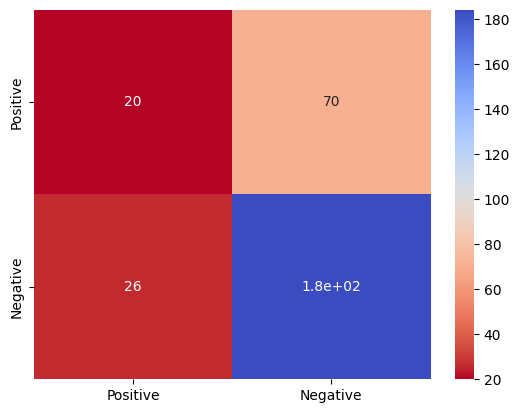

In [3552]:
matriz = pd.DataFrame(confusion_matrix(y_test , y_pred) , index = ['Positive' , 'Negative'] , columns = ['Positive' , 'Negative'])
display(matriz)

sns.heatmap(data = matriz, cmap= 'coolwarm_r' , annot = True );

In [3553]:
print(pd.DataFrame(classification_report(y_test , y_pred , output_dict= True)))

                   0           1  accuracy   macro avg  weighted avg
precision   0.434783    0.724409      0.68    0.579596      0.637521
recall      0.222222    0.876190      0.68    0.549206      0.680000
f1-score    0.294118    0.793103      0.68    0.543611      0.643408
support    90.000000  210.000000      0.68  300.000000    300.000000


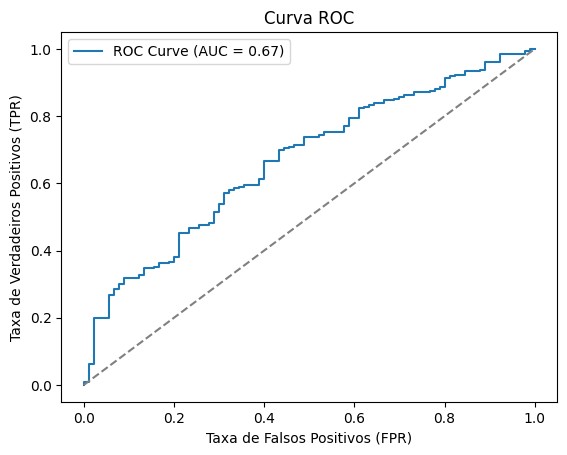

In [3554]:
y_probs = modelo_rf.predict_proba(X_test)[: ,1]
auc = roc_auc_score(y_test , y_probs)
tpr , fpr , thresholds = roc_curve(y_test , y_probs)

fig , ax = plt.subplots()
ax.plot(tpr , fpr , label=f'ROC Curve (AUC = {auc:.2f})')
ax.plot([0 , 1] ,[0 , 1] , linestyle = '--' , color = 'gray')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')

plt.legend()
plt.show()

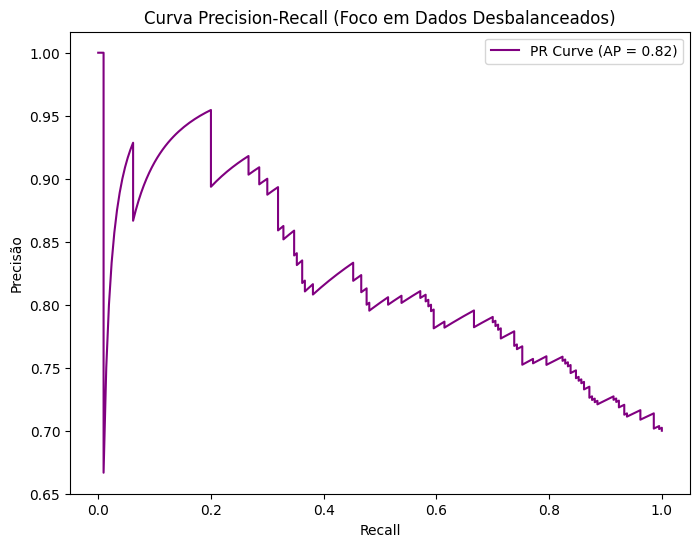

In [3555]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

ap_score = average_precision_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', label=f'PR Curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva Precision-Recall (Foco em Dados Desbalanceados)')
plt.legend()

plt.show()

In [3556]:
y_pred = np.where(y_probs > 0.7, 1 , 0)

print(pd.DataFrame(classification_report(y_test , y_pred ,output_dict= True)))

y_pred = np.where(y_probs > 0.71, 1 , 0)

print(pd.DataFrame(classification_report(y_test , y_pred ,output_dict= True)))

y_pred = np.where(y_probs > 0.75, 1 , 0)

print(pd.DataFrame(classification_report(y_test , y_pred ,output_dict= True)))

                   0           1  accuracy   macro avg  weighted avg
precision   0.379121    0.822034  0.553333    0.600577      0.689160
recall      0.766667    0.461905  0.553333    0.614286      0.553333
f1-score    0.507353    0.591463  0.553333    0.549408      0.566230
support    90.000000  210.000000  0.553333  300.000000    300.000000
                   0           1  accuracy   macro avg  weighted avg
precision   0.377660    0.830357  0.546667    0.604008      0.694548
recall      0.788889    0.442857  0.546667    0.615873      0.546667
f1-score    0.510791    0.577640  0.546667    0.544216      0.557585
support    90.000000  210.000000  0.546667  300.000000    300.000000
                   0           1  accuracy   macro avg  weighted avg
precision   0.357798    0.853659  0.493333    0.605728      0.704900
recall      0.866667    0.333333  0.493333    0.600000      0.493333
f1-score    0.506494    0.479452  0.493333    0.492973      0.487564
support    90.000000  210.000000  

In [3557]:
matriz = pd.DataFrame(confusion_matrix(y_test , y_pred) , index = ['Positivo' , 'Negativo'] , columns = ['Positivo' , 'Negativo'])
display(matriz)

,Positivo,Negativo
Positivo,78,12
Negativo,140,70


# Diagnóstico 

Foram implementados modelos de regressão logística, random forest (inclusive com profundidade ajustada), Extra Trees , XGBoost e random forest usando SMOTE no treino para ajustar os dados desbalanceados. Dentre esses modelos, ajustamos para cada um deles as curvas ROC e PR, e avaliamos assim o limiar de decisão adequado para a situação de avaliação de crédito. Comparando os modelos, podemos observar que o modelo random forest padrão, ajustado com profundidade máxima igual a 8 e pesos na classe desbalanceada obteve melhores resultados usando limiar de 0.67. O modelo obteve 80% de recall na classe bad e 45% de recall na classe good. Isso significa que 80% dos maus pagadores que pedirem crédito não vão receber, por isso o recall é uma métrica tão importante e que no contexto de score de crédito deve ser maximizada, no trade-off com o recall da classe de bons pagadores. Em nosso modelo, somente 45% dos bons pagadores que pedissem crédito receberiam. É um número relativamente alto, porém se tentassemos aumentar esse número, iriamos dar mais crédito a maus pagadores. A precisão da classe good também foi boa. Dentre as pessoas que recebem crédito , 84% são bons pagadores, enquanto que das pessoas que não recebm crédito apenas 40% são maus pagadores. 

O segundo melhor modelo foi o de random forest após o SMOTE no treino dos dados, que obteve 79% de recall na classe bad e 44% da classe good, performando apenas um pouco pior que o melhor modelo. A precisão nas pessoas evaluadas com bom score de crédito também foi um pouco pior nesse modelo com 82% contra os 84% no modelo acima. O que pudemos ver é que tentar usar o SMOTE no treino não fez tanta diferença na seleção do modelo. O que foi muito importante mesmo foi o ajuste no limiar de decisão dos modelos de classificação e a utilização de profundidade máxima combinada com pesos na classe alvo, com análise das métricas voltadas específicamente para score de crédito, que mesmo acertando 56% das vezes, se mostrou preciso na análise de crédito. 